## Sección 0: Configuración del entorno
Carga de librerías permitidas y rutas del proyecto desde el archivo `.env`

In [2]:
# Librerías permitidas
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.colors as mpl_colors
import os
from dotenv import load_dotenv

# Carga de variables de entorno desde .env
load_dotenv(dotenv_path=os.path.join(os.path.dirname(os.getcwd()), ".env"))

DATASET_PATH = os.getenv("DATASET_PATH")
TRAIN_PATH   = os.getenv("TRAIN_PATH")
TEST_PATH    = os.getenv("TEST_PATH")
CLASS_BLIGHT   = os.getenv("CLASS_BLIGHT")
CLASS_GRAY     = os.getenv("CLASS_GRAY_SPOT")
CLASS_RUST     = os.getenv("CLASS_RUST")

listas_enfermedades = [CLASS_BLIGHT, CLASS_GRAY, CLASS_RUST] # lista de plagas del maíz a clasificar

print("✅ Entorno cargado correctamente")
print(f"   TRAIN : {TRAIN_PATH}")
print(f"   TEST  : {TEST_PATH}")
print(f"   Plagas: {listas_enfermedades}")

✅ Entorno cargado correctamente
   TRAIN : ../data/PlantDoc-Dataset/train
   TEST  : ../data/PlantDoc-Dataset/test
   Plagas: ['Corn leaf blight', 'Corn Gray leaf spot', 'Corn rust leaf']


## Sección 1: Exploración del dataset
cuántas imágenes hay por enfermedades (plagas), cómo lucen visualmente y qué características generales tienen.

In [3]:
# Conteo de imágenes por plagas en los datos de entrenamiento y prueba (train/test)
print("=" * 50)
# La 'f' antes de las comillas indica un "f-string" (Formato de texto).
print(f"{'PLAGA':<30} {'TRAIN':>6} {'TEST':>6}")
print("=" * 50)

conteo_imagenes = {}
for enfermedad in listas_enfermedades:
    path_train = os.path.join(TRAIN_PATH, enfermedad)
    path_test  = os.path.join(TEST_PATH, enfermedad)

# f: variable temporal que representa cada 'archivo/file' dentro de las carpetas (se usa la f por convención de programadores).
    imgs_train = len([f for f in os.listdir(path_train)
                      if f.lower().endswith(('.jpg','.jpeg','.png'))])# .lower(): convierte a minúsculas para evitar errores con extensiones en Mayúsculas.
    imgs_test  = len([f for f in os.listdir(path_test)# len(): cuenta cuántos archivos pasaron el filtro con éxito.
                      if f.lower().endswith(('.jpg','.jpeg','.png'))]) # .endswith: filtro de seguridad para contar solo imágenes (.jpg, .jpeg, .png).

# Guarda los resultados en el diccionario: La 'llave' es el nombre de la enfermedad y el 'valor' es otro diccionario con los conteos.
    conteo_imagenes[enfermedad] = {"train": imgs_train, "test": imgs_test}
    print(f"{enfermedad:<30} {imgs_train:>6} {imgs_test:>6}")

print("=" * 50)
total_train = sum(v["train"] for v in conteo_imagenes.values()) # v: representa cada 'Valor' (el par de números train/test) dentro del diccionario.
total_test  = sum(v["test"]  for v in conteo_imagenes.values()) # .values(): le dice a Python que ignore los nombres de las plagas y solo mire los números.
print(f"{'TOTAL':<30} {total_train:>6} {total_test:>6}")

PLAGA                           TRAIN   TEST
Corn leaf blight                   47     12
Corn Gray leaf spot                30      3
Corn rust leaf                     28     10
TOTAL                             105     25


In [ ]:
#  Función auxiliar para cargar imágenes de una categoría especifica del dataset, con un umbral de 'n' unidades.
def cargar_imagenes_clase(tipo_plaga, split="train", n=3):

    # Selecciona la carpeta base según el split o conjunto de datos solicitado (train/test).
    carpeta_base = TRAIN_PATH if split == "train" else TEST_PATH #sNo confundas split con .split(), que se usa p ej: "hola mundo".split() te daría ['hola', 'mundo'])
    ruta = os.path.join(carpeta_base, tipo_plaga)
    
    # Filtra archivos por extensión y limita a 'n' unidades (3 en este caso). La 'f' representa cada 'archivo' dentro de la carpeta.
    archivos = [f for f in os.listdir(ruta)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:n]
    
    imagenes = []
    for archivo in archivos:
        # Abrimos la imagen (img), y aseguramos RGB y luego convertimos a matriz (Array)
        img = Image.open(os.path.join(ruta, archivo)).convert("RGB")
        imagenes.append(np.asarray(img))
        
    return imagenes

# Configuración del lienzo para mostrar las imagenes: 3 filas (enfermedades) x 3 columnas (muestras por enfermedad)
fig, axes = plt.subplots(3, 3, figsize=(16, 10)) # figsize: tamaño del lienzo (ancho x alto) en pulgadas.

# Ciclo de visualización donde usamos la variable temporal 'enfermedad' para no sobrescribir la lista original 'listas_enfermedades'
for fila, enfermedad in enumerate(listas_enfermedades):
    
    # Cargamos las n fotos para la enfermedad actual
    imagenes = cargar_imagenes_clase(enfermedad)
    
    for columna, img in enumerate(imagenes):
        # Dibujamos la imagen
        axes[fila, columna].imshow(img)
        axes[fila, columna].axis("off") # Quita los ejes para una mejor visualización
        
        # Agregamos el nombre de la enfermedad a la izquierda de la primera columna (columna 0) de cada fila.
        if columna == 0:
            axes[fila, columna].text(-0.2, 0.5, enfermedad, # coordenadas horizontal y vertical (x,y) para colocar el texto fuera de la imagen
                                 transform=axes[fila, columna].transAxes, 
                                 fontsize=12, 
                                 fontweight="bold", 
                                 ha="right", # horizontal alineación (ha): alinea el texto a la derecha del punto especificado
                                 va="center")# vertical alineación (va): centra el texto verticalmente respecto al punto especificado.

# Título general para todo el lienzo
plt.suptitle("Muestras del dataset — 3 enfermedades del maíz", 
             fontsize=18, 
             fontweight="bold", 
             y=1.05,
             x=0.625)

# Ajuste automático
plt.tight_layout()

# Ajuste manual: left=0.25 para que los nombres tengan espacio
# hspace=0.30 para separar las filas 
plt.subplots_adjust(left=0.25, hspace=0.30)

plt.show()

### Características Visuales

A continuación se describen las características morfológicas y de textura de cada enfermedad observadas en el dataset:

| Clase de Enfermedad | Características de **Textura y Forma** |
| :--- | :--- |
| **Corn leaf blight** (Tizón) | Presenta lesiones **macroscópicas** en forma de "puros" o elipses alargadas. Los bordes tienen un **gradiente de intensidad** alto (transición abrupta de verde a café). |
| **Corn Gray leaf spot** (Mancha Gris) | Lesiones **geométricas y rectangulares**. Siguen un patrón lineal limitado por las nervaduras. Color neutro/gris con **bajo contraste cromático**. |
| **Corn rust leaf** (Roya) | No son manchas planas, sino **pústulas (relieve)**. Textura rugosa o "granulada". Distribución aleatoria y circular. |

---

## Sección 2 — Tarea 1: Espacios de color

Una imagen digital en RGB se representa como una matriz tridimensional 
de forma (Alto, Ancho, 3), donde cada canal almacena valores de intensidad 
entre 0 y 255 para rojo, verde y azul respectivamente.

En procesamiento de imágenes es útil convertir entre espacios de color porque:
- **YUV** separa la luminancia (brillo) de la crominancia (color), útil para 
  analizar intensidad independientemente del color
- **HSV** separa el Tono o Matiz (Hue), la Saturación (pureza del color) y el Valor (brillo). 
Este modelo es más cercano a cómo los humanos percibimos el color, permitiendo identificar un color específico
(como el verde de una hoja) sin que le afecten tanto las sombras o los reflejos.

Ambas conversiones se deben implementar **manualmente usando la librerias permitidas cono NumPy**, 
sin usar funciones automáticas de librerías de visión por computador.

In [5]:
# Cargar una imagen de cada clase/enfermedad
def cargar_primera_imagen(enfermedad, split="train"):

    carpeta_base = TRAIN_PATH if split == "train" else TEST_PATH
    ruta = os.path.join(carpeta_base, enfermedad)
    archivos = [f for f in os.listdir(ruta)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    img = Image.open(os.path.join(ruta, archivos[0])).convert("RGB")# Toma la primera imagen de la carpeta (archivos[0]) y la convierte a RGB , luego la convierte a un array de numpy para facilitar su manipulación.
    return np.asarray(img)

img_blight   = cargar_primera_imagen(CLASS_BLIGHT)# Tizón
img_gray     = cargar_primera_imagen(CLASS_GRAY)# Mancha Gris
img_rust     = cargar_primera_imagen(CLASS_RUST)# Roya

# Trabajaremos con blight como imagen principal creamos usamos una copia para realizar modificaciones sin modificarla img original directamente.
imagen = img_blight.copy()

print(f"Dimensiones de la imagen: {imagen.shape}")
print(f"Tipo de dato            : {imagen.dtype}")
print(f"Valor mínimo            : {imagen.min()}")
print(f"Valor máximo            : {imagen.max()}")

Dimensiones de la imagen: (356, 800, 3)
Tipo de dato            : uint8
Valor mínimo            : 0
Valor máximo            : 255


### Separación de canales RGB

Desde de la imagen original 
para visualizarlos individualmente. Donde cada canal genera una matriz 2D con valores 
entre 0 y 255 que representa la intensidad de ese color en cada píxel.

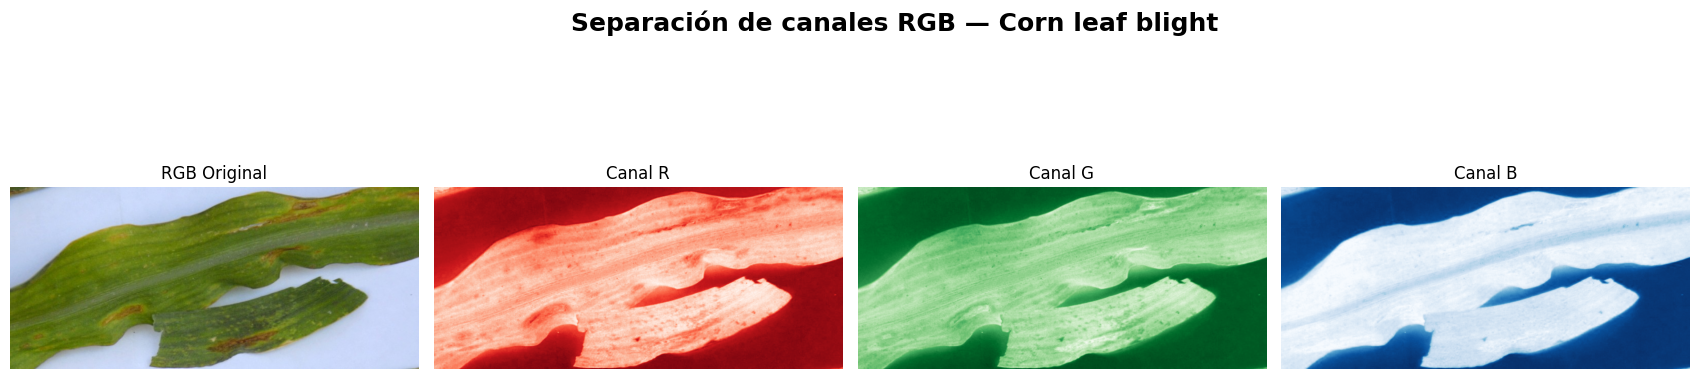

In [ ]:
# Separar canales de color RGB
# el símbolo ':' se usa para seleccionar todas las filas y columnas, mientras que el número después de la coma indica el canal específico (0 para R, 1 para G, 2 para B).
canal_R = imagen[:, :, 0]
canal_G = imagen[:, :, 1]
canal_B = imagen[:, :, 2]
# Creamos el lienzo para mostrar la imagen original y los canales separados (1 fila, 4 columnas) y configuramos el tamaño del lienzo a 18 pulgadas de ancho y 4 pulgadas de alto.
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(imagen)
axes[0].set_title("RGB Original")
axes[0].axis("off")

axes[1].imshow(canal_R, cmap="Reds")
axes[1].set_title("Canal R")
axes[1].axis("off")

axes[2].imshow(canal_G, cmap="Greens")
axes[2].set_title("Canal G")
axes[2].axis("off")

axes[3].imshow(canal_B, cmap="Blues")
axes[3].set_title("Canal B")
axes[3].axis("off")

plt.suptitle(f"Separación de canales RGB — {CLASS_BLIGHT}", fontsize=18, fontweight="bold", y=1.08)
#rect = [izquierda, abajo, derecha, arriba]
plt.tight_layout(rect=[0, 0, 0.95, 0.92])
plt.show()


### Análisis de Canales RGB: ¿Cuál detecta mejor la enfermedad?

Al separar la imagen original en sus tres componentes básicos (Rojo, Verde y Azul), observamos cómo reacciona la luz ante la enfermedad:

1. **Filtro Rojo (Canal R):** Resaltar la enfermedad. Debido a que las manchas del hongo son de color café/rojizo, en este canal se ven mucho más claro. 
2. **Filtro Verde (Canal G):** Este canal nos muestra la "salud" de la planta. La hoja sana se ve muy clara (brillante), pero donde está la mancha, el color se vuelve oscuro. Es útil para ver qué tanta parte de la hoja ha dejado de ser verde, pero no resalta la mancha tan bien como el rojo.
3. **Filtro Azul (Canal B):** Es el menos útil. La imagen se ve muy oscura y plana. Solo sirve para distinguir la silueta de la hoja frente al fondo blanco.

**Conclusión:** Si tuviéramos que elegir un solo canal para que una computadora detecte la enfermedad de forma sencilla, el **Canal Rojo** es el más adecuado porque "ilumina" las lesiones necróticas.

---
---

### Conversión de Espacio de Color: RGB → YUV

La conversión del modelo **RGB** (basado en la mezcla de aditiva de luz) al modelo **YUV** (basado en la percepción de brillo y color) permite analizar la estructura de la imagen independientemente de su información cromática.

#### Proceso de Cálculo
Para realizar la conversión manualmente con NumPy, primero debemos **normalizar** los canales al rango $[0, 1]$ dividiendo cada valor entre 255. Luego, se aplica la matriz de transformación estándar:

$$Y = 0.299R + 0.587G + 0.114B$$
$$U = -0.147R - 0.289G + 0.436B$$
$$V = 0.615R - 0.515G - 0.100B$$

---
#### Definición de Componentes

* **Y (Luminancia):** Representa el brillo o la intensidad de la luz en la imagen. Es el canal que veríamos en una fotografía en blanco y negro. El ojo humano es más sensible al verde, por ello su coeficiente ($0.587$) es el más alto.
* **U (Crominancia - Diferencia de Azul):** Indica la presencia de tonos azules frente a sus opuestos (amarillos). 
    * **U ↑ :** La imagen tiende hacia el azul.
    * **U ↓ :** La imagen tiende hacia el amarillo.
* **V (Crominancia - Diferencia de Rojo):** Indica la presencia de tonos rojos frente a sus opuestos (cian).
    * **V ↑:** La imagen tiende hacia el rojo.
    * **V ↓ :** La imagen tiende hacia el cian (verde-azulado).

> **Nota técnica:** Separar la luminancia (**Y**) es fundamental en agricultura de precisión, ya que permite detectar texturas y patrones de manchas de enfermedades sin que las variaciones de tono confundan el análisis.


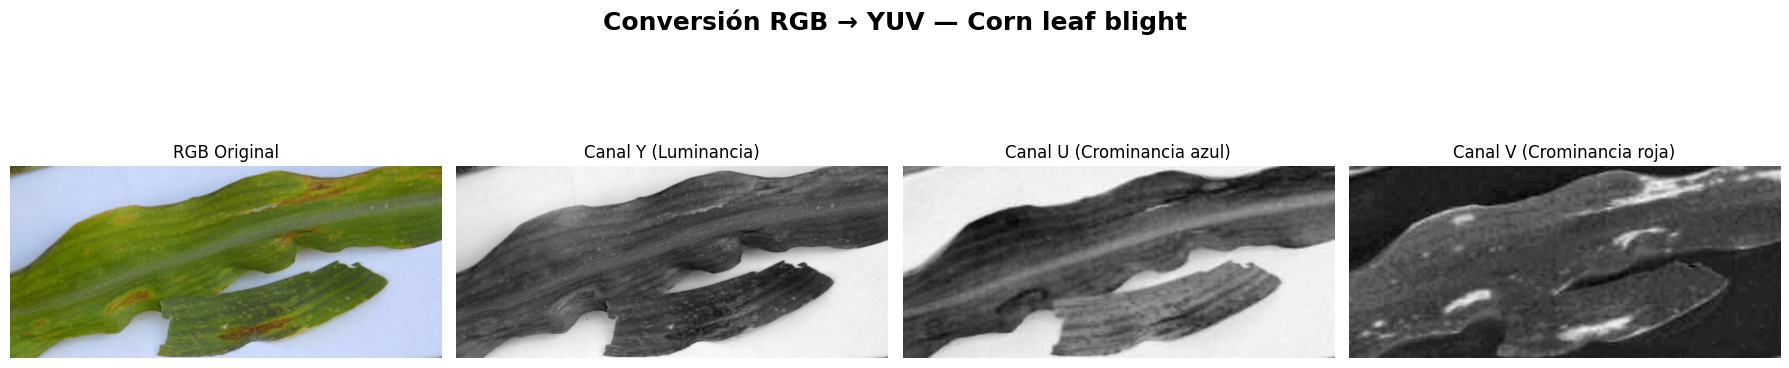

In [8]:
def rgb_a_yuv(imagen_rgb):
    """
    Convierte una imagen RGB a espacio de color YUV.    
    Parámetros:
        imagen_rgb : array NumPy (H, W, 3) con valores uint8 [0, 255]    
    Retorna:
        imagen_yuv : array NumPy (H, W, 3) con valores float64
    """
    rgb_norm = imagen_rgb / 255.0

    matriz = np.array([
        [ 0.299,  0.587,  0.114],#coeficientes para calcular la luminancia (Y) a partir de los canales R, G y B.
        [-0.147, -0.289,  0.436],#"" "" crominancia (U)
        [ 0.615, -0.515, -0.100] #"" "" crominancia (V).
    ])
#Empleamos el simbolo '@' para multiplicar cada pixel RGB normalizado por matriz transpuesta (matriz.T),
#para obtener los valores YUV correspondientes mediante álgebra lineal.
    imagen_yuv = rgb_norm @ matriz.T
    return imagen_yuv

imagen_yuv = rgb_a_yuv(imagen)#tomamos la foto original de la hoja de maíz (imagen) y la convierte a espacio de color YUV usando la función rgb_a_yuv. El resultado se almacena en imagen_yuv.

#separar canales YUV
canal_Y = imagen_yuv[:, :, 0]#extrae la primera capa (Y) de la imagen YUV, que representa la luminancia o brillo de la imagen.
canal_U = imagen_yuv[:, :, 1]# "" "" segunda (U) de la imagen YUV, que representa la crominancia azul (la diferencia entre el canal azul y la luminancia).
canal_V = imagen_yuv[:, :, 2]#"" "" tercera capa (V) de la imagen YUV, que representa la crominancia roja (la diferencia entre el canal rojo y la luminancia).

#creamos el lienzo 
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(imagen)
axes[0].set_title("RGB Original")
axes[0].axis("off")

axes[2].imshow(canal_U, cmap="gray")
axes[2].set_title("Canal U (Crominancia azul)")
axes[2].axis("off")

axes[1].imshow(canal_Y, cmap="gray")#cmap="gray" se usa para mostrar la imagen en escala de grises
axes[1].set_title("Canal Y (Luminancia)")
axes[1].axis("off")

axes[3].imshow(canal_V, cmap="gray")
axes[3].set_title("Canal V (Crominancia roja)")
axes[3].axis("off")

plt.suptitle(f"Conversión RGB → YUV — {CLASS_BLIGHT}", fontsize=18, fontweight="bold", y=1.08)
plt.tight_layout()
plt.show()

### Análisis de la conversión de RGB -> YUV (Caso Corn Leaf Blight)

La conversión permite descomponer la imagen en brillo (Luminancia) y color (Crominancia), revelando patrones que el ojo humano ignora en la imagen original:

1. **Canal Y (Luminancia):** Representa la estructura de la hoja en escala de grises. Aunque define bien la forma, el **contraste es bajo** entre el tejido sano y la lesión del tizón (*Blight*), ya que ambos reflejan niveles de luz similares. No es el canal ideal para segmentación en este caso.

2. **Canal U (Crominancia Azul):** Muestra la diferencia entre el componente azul y la luminancia. Este canal suele ser el menos informativo (se observa muy plano) debido a la ausencia de pigmentos azules en la vegetación y la patología.

3. **Canal V (Crominancia Roja):** Este canal es el **más efectivo para la detección**. Al medir la intensidad del componente rojo/café, las manchas de la enfermedad aparecen como **zonas blancas brillantes (valores altos)** sobre una hoja oscura (valores bajos). 
   * **Ventaja:** Elimina el "ruido" del color verde y se enfoca exclusivamente en el pigmento necrótico de la enfermedad.

**Conclusión:** El **Canal V** permite aplicar un umbral (threshold) simple para aislar las manchas, facilitando el cálculo automático del porcentaje de área afectada sin confusión por variaciones de iluminación.

---

### Conversión de espacio del color: RGB → HSV

A diferencia de RGB, el modelo **HSV** (*Hue, Saturation, Value*) organiza el color de una forma más cercana a la percepción humana, lo que facilita la segmentación de tejidos vegetales (hojas sanas vs. manchas de enfermedad).

#### Definición de Componentes:

* **H (Hue / Tono):** Representa el color puro (ej. verde, amarillo, rojo). En teoría se mide en grados ($0^\circ$ a $360^\circ$), pero en esta implementación se normaliza al rango $[0, 1]$.
* **S (Saturation / Saturación):** Indica la "pureza" del color. Un valor de $0$ es gris/blanco y $1$ es el color totalmente intenso.
* **V (Value / Valor):** Representa el brillo o intensidad de la luz. $0$ es negro total y $1$ es el brillo máximo del color.

> **Nota técnica:** Para esta conversión utilizamos `matplotlib.colors.rgb_to_hsv()`. Es importante notar que esta es una función de transformación matemática de matrices y no una herramienta de procesamiento de imágenes (como OpenCV).

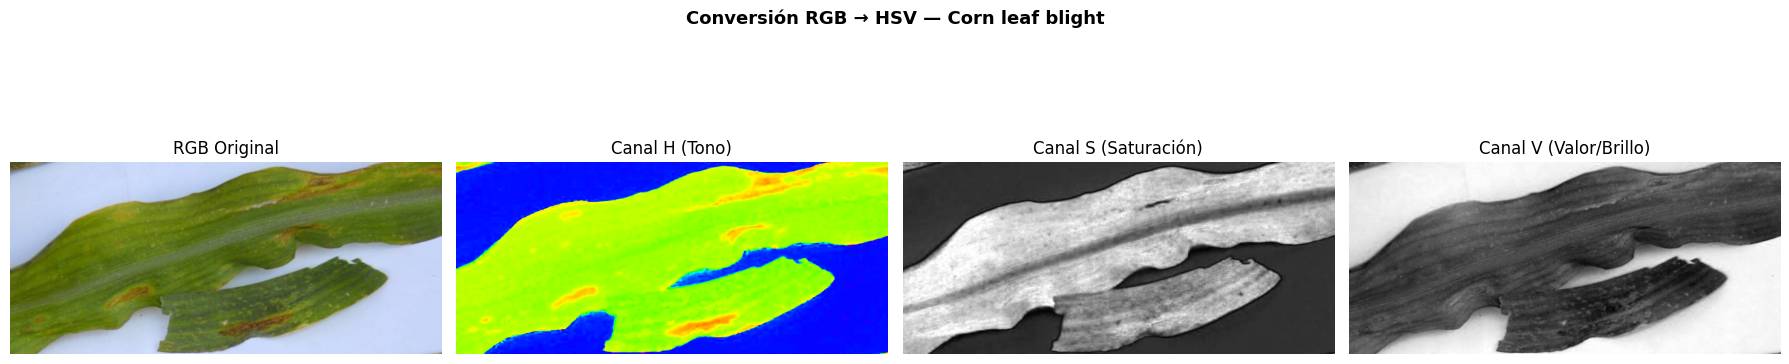

In [9]:
def rgb_a_hsv(imagen_rgb):
    """
    Convierte una imagen RGB a espacio de color HSV.    
    Parámetros:
        imagen_rgb : array NumPy (H, W, 3) con valores uint8 [0, 255]
    Retorna:
        imagen_hsv : array NumPy (H, W, 3) con valores float64 [0, 1]
    """
    rgb_norm = imagen_rgb / 255.0
    imagen_hsv = mpl_colors.rgb_to_hsv(rgb_norm)
    return imagen_hsv


imagen_hsv = rgb_a_hsv(imagen)

canal_H = imagen_hsv[:, :, 0]
canal_S = imagen_hsv[:, :, 1]
canal_V = imagen_hsv[:, :, 2]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(imagen)
axes[0].set_title("RGB Original")
axes[0].axis("off")

axes[1].imshow(canal_H, cmap="hsv")
axes[1].set_title("Canal H (Tono)")
axes[1].axis("off")

axes[2].imshow(canal_S, cmap="gray")
axes[2].set_title("Canal S (Saturación)")
axes[2].axis("off")

axes[3].imshow(canal_V, cmap="gray")
axes[3].set_title("Canal V (Valor/Brillo)")
axes[3].axis("off")

plt.suptitle(f"Conversión RGB → HSV — {CLASS_BLIGHT}", fontsize=13, fontweight="bold", y=1.08)
plt.tight_layout()
plt.show()

### Análisis de Resultados: Espacio de Color HSV

La conversión a **HSV** demuestra ser una herramienta clave para la segmentación de **Corn Leaf Blight** debido a la separación de atributos:

* **Canal H (Tono):** Permite diferenciar claramente el tejido sano (verde/amarillo) de las lesiones necróticas (tonos rojizos/naranjas).
* **Canal S (Saturación):** Resalta la "pureza" del color, siendo útil para separar la hoja del fondo grisáceo o ruidoso.
* **Canal V (Valor):** Identifica variaciones de iluminación y sombras, pero no discrimina la enfermedad tan bien como el canal H (Tono).

Conclusión:
Para delimitar las manchas del tizón, el Canal H (Tono) es el más adecuado. Al aislar el color puro, elimina por completo las sombras y variaciones de luz (ruido).

---

### Comparativa final — Las tres enfermedades en los tres espacios de color RGB; YUV; HSV

Aplicamos las conversiones a las tres clases o enferemedades para observar si los 
espacios de color permiten diferenciar visualmente las enfermedades.

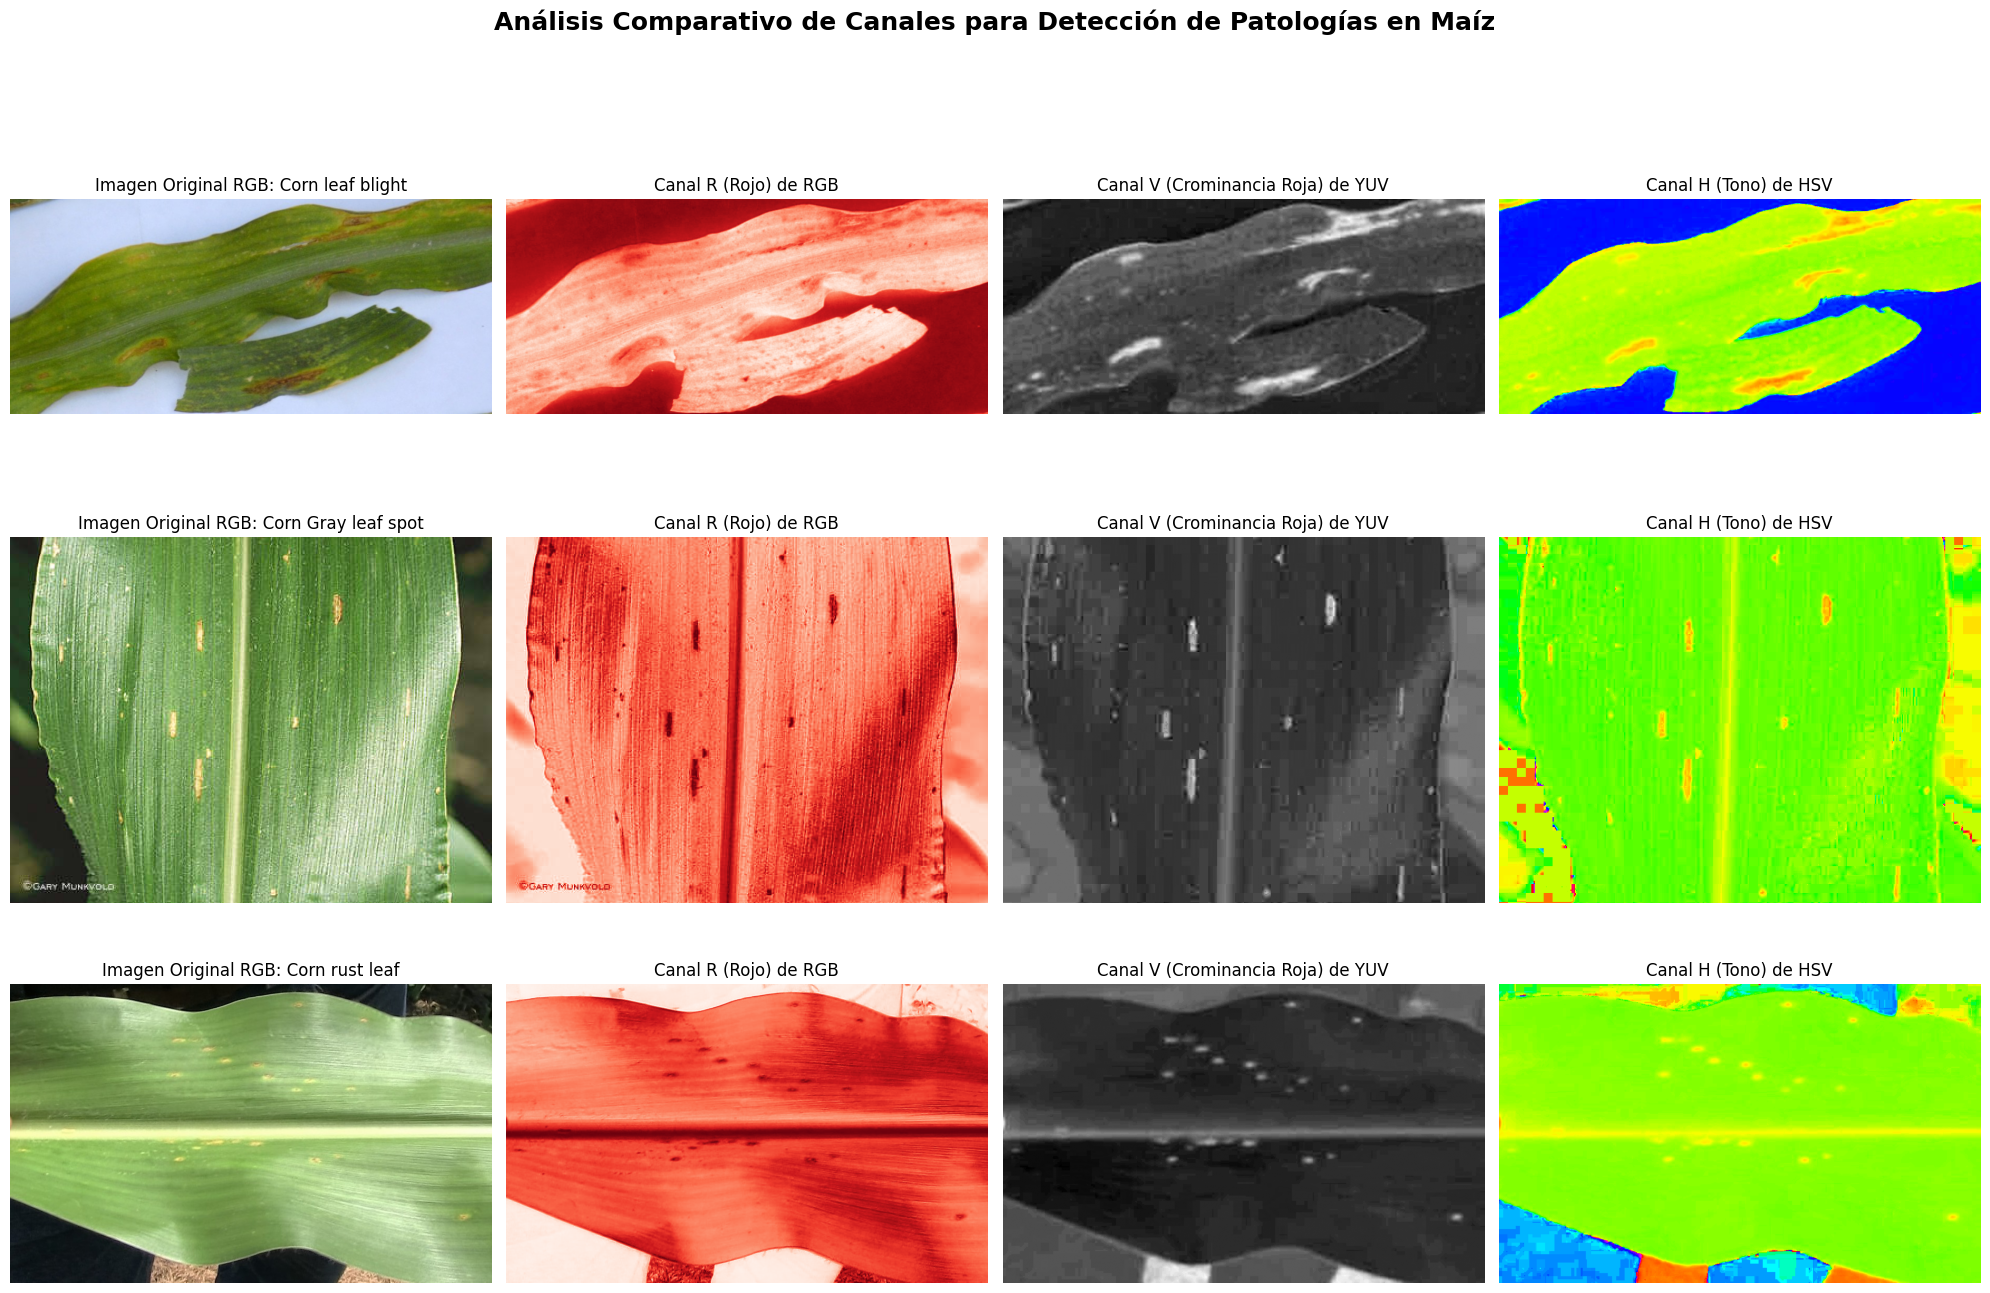

In [12]:
#creamos un diccionario para almacenar las imágenes originales de cada clase/enfermedad, usando los nombres de las clases como llaves y las imágenes como valores.
imagenes_clase = {
    CLASS_BLIGHT : img_blight,
    CLASS_GRAY   : img_gray,
    CLASS_RUST   : img_rust
}
#creamos el lienzo para mostrar las imágenes originales y sus canales, RGB, YUV y HSV correspondientes 
# (3 filas para cada enfermedad y 4 columnas para imagen original RGB,canal R de rgb; YUV y HSV) y configuramos el tamaño del lienzo ancho y alto en pulgadas 
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

# El bucle recorre las 3 enfermedades del diccionario
for fila, (nombre, img) in enumerate(imagenes_clase.items()):
    # Conversiones de color
    yuv = rgb_a_yuv(img)
    hsv = rgb_a_hsv(img)
    
    # Extraemos el canal Rojo (índice 0 en RGB)
    canal_R = img[:, :, 0] 

    #  Columna 0: Imagen RGB original  
    axes[fila, 0].imshow(img)
    axes[fila, 0].set_title(f"Imagen Original RGB: {nombre}", fontsize=12)

    #  Columna 1: Canal R (Rojo de RGB)  
    axes[fila, 1].imshow(canal_R, cmap="Reds") 
    axes[fila, 1].set_title("Canal R (Rojo) de RGB", fontsize=12)

    #  Columna 2: Canal V de YUV (Crominancia Roja)  
    # Usamos el índice 2 para el canal V
    axes[fila, 2].imshow(yuv[:, :, 2], cmap="gray")
    axes[fila, 2].set_title("Canal V (Crominancia Roja) de YUV", fontsize=12)

    #  Columna 3: Canal H de HSV (Tono)  
    # Usamos el índice 0 para el canal H
    axes[fila, 3].imshow(hsv[:, :, 0], cmap="hsv")
    axes[fila, 3].set_title("Canal H (Tono) de HSV", fontsize=12)

    #  Limpieza y Etiquetas 
    for col in range(4):
        axes[fila, col].axis("off") # Quitamos los números de los ejes

#Título general para toda la figura
plt.suptitle("Análisis Comparativo de Canales para Detección de Patologías en Maíz", 
             fontsize=18, y=0.95, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste para que el título no tape las imágenes
plt.show()

### Análisis de Resultados — Sobre los Canales (R, V, H)

Al descomponer las imágenes de las tres patologías (*Blight, Gray Spot, Rust*) mediante Procesamiento Digital de Imágenes (PDI), se identifican los canales con mayor capacidad de discriminación:

| Canal / Espacio | Observaciones Técnicas en el Dataset de Maíz | Utilidad para el Procesamiento (PDI) |
| :--- | :--- | :--- |
| **Canal R (Rojo de RGB)** | Las lesiones fúngicas presentan pigmentos necróticos (cafés/oxidados). En este canal, la enfermedad aumenta su reflectancia, apareciendo como zonas claras que contrastan con el tejido verde oscuro de la hoja sana. | Útil para detección rápida; ofrece un contraste inmediato sin necesidad de transformaciones complejas de color. |
| **Canal V (Crominancia Roja - YUV)** | Es el canal con mayor **relación señal-ruido**. Al aislar la componente de color y descartar la luminancia, las manchas de *Blight*, *Gray spot* y *Rust* resaltan como blanco puro sobre un fondo negro, eliminando sombras e iluminación irregular. | **El mejor para binarización**. Permite aplicar un umbral (threshold) simple para extraer la máscara exacta del área afectada. |
| **Canal H (Tono - HSV)** | Permite separar el espectro del verde (hoja sana) de los amarillos y naranjas (patógeno), independientemente de qué tan brillante sea la toma. | Crucial para la **clasificación**. Ayuda a identificar la enfermedad según su "firma de color" que es como la huella dactilar de la enfermedad.|

### Conclusión Técnica

Se determina que el **Canal V (del espacio YUV)** es superior al Canal Rojo de RGB para la segmentación, ya que normaliza las variaciones de luz.

**Estrategia propuesta:**
1. **Segmentación:** Utilizar el **Canal V (YUV)** para generar una máscara binaria que aísle las lesiones del resto de la hoja.
2. **Clasificación:** Superponer dicha máscara sobre el **Canal H (HSV)** para medir el tono exacto y diferenciar, por ejemplo, el café oscuro del *Blight* frente al naranja intenso de la *Roya*.
3. **Morfología:** La nitidez del Canal V permite medir con precisión el área (píxeles) y la forma de la mancha para determinar la severidad de la infección.


---

## Sección 3 — Tarea 2: Histograma, CDF, Umbralización y Otsu

El histograma es el primer paso fundamental en procesamiento de imágenes.
Nos indica cuántos píxeles tienen cada valor de intensidad posible (0–255),
lo que permite entender la distribución de brillo y color en la imagen.

A partir del histograma se construyen herramientas más avanzadas:
- **CDF** (Función de Distribución Acumulada): acumula las frecuencias 
  del histograma, útil para ecualización y análisis de contraste
- **Umbralización manual**: separar píxeles en dos grupos (fondo/objeto) 
  usando un valor de corte definido visualmente
- **Método de Otsu**: encontrar el umbral óptimo automáticamente 
  maximizando la varianza entre las dos clases de píxeles resultantes Clase 1 — El Fondo (Background): En nuestro caso, sería la parte sana de la hoja o el fondo de la imagen.
  Clase 2 — El Objeto de interés (Foreground): En nuestro caso, serian las manchas de la enfermedad.
---

### Implementación del histograma

El histograma se calcula recorriendo todos los valores posibles de 
intensidad (0 a 255) y contando cuántos píxeles tienen exactamente 
ese valor usando `numpy.count_nonzero`.

La función retorna dos arreglos:
- `histograma`: frecuencia de cada valor de intensidad
- `xticks`: valores del eje horizontal (0 a 255)

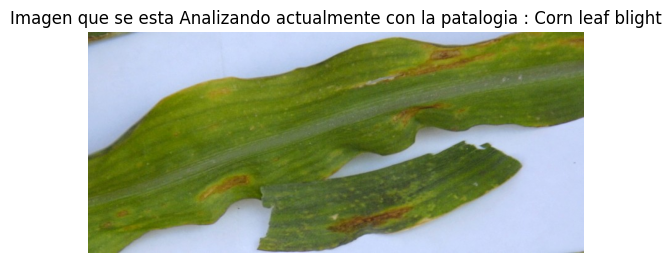

Histogramas calculados correctamente para canales RGB y V(YUV)
Dimensiones de la imagen: 356x800px
Píxeles totales según la matriz: 284800
Píxeles contados en el Canal Rojo: 284800
Píxeles contados en el Canal V (YUV): 284800
¡Verificación exitosa! Los histogramas contienen exactamente el 100% de los píxeles.


In [16]:
def calcular_histograma(canal):
    """
    Calcula el histograma de un canal de imagen.
    Parámetros:
        canal : array NumPy 2D con valores enteros en [0, 255]
    Retorna:
        histograma : array de 256 frecuencias
        xticks     : array de valores [0, 1, ..., 255]
    """
    # xticks: indica los valores de intensidad posibles (0 a 255) y se usa para etiquetar el eje X.
    xticks = np.arange(256)
    histograma = np.zeros(256, dtype=np.int64)

    for valor in xticks:
        histograma[valor] = np.count_nonzero(canal == valor)

    return histograma, xticks

# Calcular histograma de cada canal sobre la imagen principal Tizón (blight) es tu matriz de la hoja, esta imagen es justamente esta "imagen = img_blight.copy()"
yuv_img = rgb_a_yuv(imagen)

# Multiplicamos el Canal V (índice 2) por 255 y lo convertimos a enteros (uint8)
# Esto "estira" los valores decimales para que ocupen el rango 0-255
canal_v_listo = (yuv_img[:, :, 2] * 255).astype(np.uint8)

# Calculamos el histograma del canal 0 (Rojo). 
# Guardamos los conteos en 'hist_R' y las etiquetas 0-255 en 'xt'
hist_R, xt = calcular_histograma(imagen[:, :, 0])
# Calculamos el del canal 1 (Verde). 
# El '_' significa que ignoramos los xticks porque son los mismos (0-255).
hist_G, _  = calcular_histograma(imagen[:, :, 1])
hist_B, _  = calcular_histograma(imagen[:, :, 2])

# Calculamos el del canal 2 del espacio YUV (Canal V).
# Aquí 'yuv_img' es la versión convertida de tu imagen original.
hist_V, _  = calcular_histograma(canal_v_listo) # Usamos el canal ya corregido

plt.imshow(imagen)
plt.title(f"Imagen que se esta Analizando actualmente con la patalogia : {CLASS_BLIGHT}")
plt.axis("off")# desactivamos el título y los ejes para una mejor visualización de la imagen
plt.show()

# Imprimimos algunos datos para verificar que los histogramas se calcularon correctamente
print("Histogramas calculados correctamente para canales RGB y V(YUV)")
print(f"Dimensiones de la imagen: {imagen.shape[0]}x{imagen.shape[1]}px")

# Sumamos todos los casilleros de cada histograma
total_pixeles_R = np.sum(hist_R)
total_pixeles_V = np.sum(hist_V)
total_matriz = imagen.shape[0] * imagen.shape[1]

print(f"Píxeles totales según la matriz: {total_matriz}")
print(f"Píxeles contados en el Canal Rojo: {total_pixeles_R}")
print(f"Píxeles contados en el Canal V (YUV): {total_pixeles_V}")

# Verificación automática
if total_pixeles_R == total_matriz and total_pixeles_V == total_matriz:
    print("¡Verificación exitosa! Los histogramas contienen exactamente el 100% de los píxeles.")
else:
    print("Error: Los histogramas no coinciden con el tamaño de la imagen.")

---
### Comparación de Distribución: Canales RGB vs. Canal V (YUV)
Graficamos y contrastamos los histogramas de cada canal para demostrar matemáticamente por qué los canales tradicionales (RGB) fallan al segmentar las enfermedades de la hoja de maiz y por qué el Canal V (YUV) es la solución óptima.

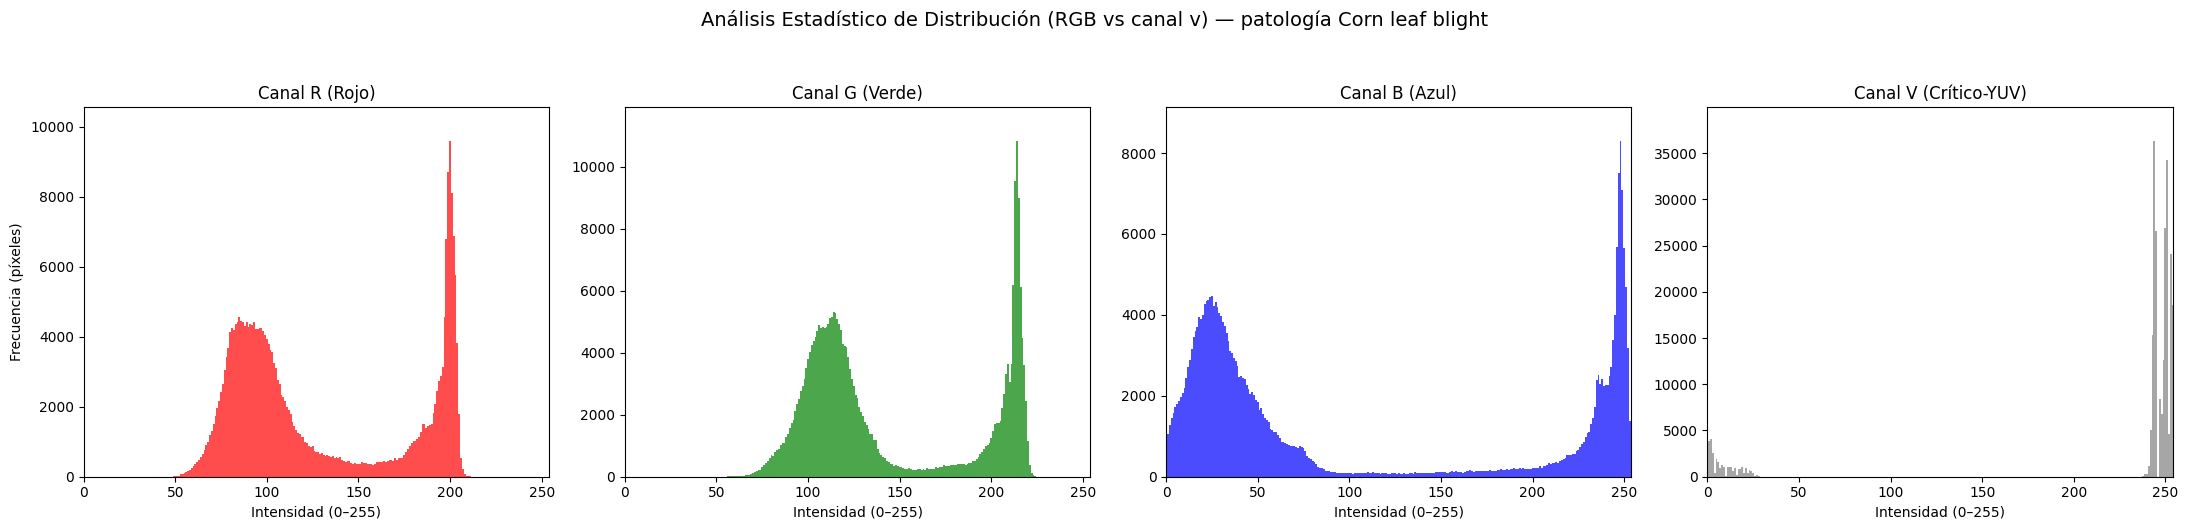

In [24]:
# Configuración del lienzo (4 col) para los histogramas de R, G, B y V(YUV)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Lista de datos (Incluimos el V que calculamos antes)
canales = [hist_R, hist_G, hist_B, hist_V]
colores = ["red", "green", "blue", "gray"]
titulos = ["Canal R (Rojo)", "Canal G (Verde)", "Canal B (Azul)", "Canal V (Crítico-YUV)"]

for i in range(4):
    axes[i].bar(xt, canales[i], color=colores[i], alpha=0.7, width=1)
    axes[i].set_title(titulos[i], fontsize=12)
    axes[i].set_xlabel("Intensidad (0–255)")
    
    # AJUSTE 1: Limitamos a 254 para para NO ver el pico gigante del fondo blanco (255) y no se arruine la escala del gráfico.
    axes[i].set_xlim([0, 254]) 
    
    # AJUSTE 2: Escalado inteligente. 
    # Buscamos el valor más alto en el histograma IGNORANDO el blanco del fondo.
    max_val = np.max(canales[i][0:250]) 
    axes[i].set_ylim([0, max_val * 1.1]) # Le damos un 10% de aire arriba

axes[0].set_ylabel("Frecuencia (píxeles)")

plt.suptitle(f"Análisis Estadístico de Distribución (RGB vs canal v) — patología {CLASS_BLIGHT}", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

### Análisis Estadístico de Distribución (RGB vs canal v)

Tras la normalización del Canal V (Crominancia roja/azul) al rango [0, 255], se observan las siguientes firmas digitales en la imagen de Corn Leaf Blight:

1. **Inutilidad de RGB para Segmentación:**
1. Canal R (Rojo)
Gráfico: Una gran montaña central (60–130) y un pico alto a la derecha (~200).
Por qué no sirve: La hoja sana absorbe el rojo (montaña oscura) y las manchas café-rojizas lo reflejan (pico claro). Sin embargo, hay tantos datos mezclados en todo el centro que es imposible trazar una línea de corte limpia sin confundir tejido sano con enfermedad.

2. Canal G (Verde)
Gráfico: Masa principal en el centro (90–140) y un pico muy agudo a la derecha (~215).
Por qué no sirve: Al ser una planta, el verde domina en toda la superficie. Como las lesiones (marrón-amarillentas) también contienen mucho verde, la enfermedad se camufla y se mezcla estadísticamente con la hoja sana, anulando este canal para separarlas.

3. Canal B (Azul)
Gráfico: Todos los datos acumulados a la izquierda (0–60) y un pico vertical gigante a la derecha (~250).
Por qué no sirve: La vegetación no tiene pigmentos azules y absorbe este canal por completo; por eso, tanto la hoja sana como la enferma se ven igual de oscuras y sin contraste a la izquierda. El pico de la derecha es solo el fondo blanco de la imagen. No aporta información útil.

4. Canal V (Crítico-YUV)
Gráfico: Un grupo pequeño a la izquierda (0–23), picos masivos acumulados al extremo derecho (240–254) y el centro (50–230) completamente vacío.
Por qué sí sirve: Al transformar los datos, la enfermedad se desplaza por completo al extremo oscuro (izquierda), separándose limpiamente de la hoja sana (derecha).

5. **Conclusión**
A diferencia de los canales RGB donde las intensidades de la hoja y la enfermedad están mezcladas, el Canal V (YUV) limpia la zona central del histograma.

**Umbral sugerido:** Dado que la enfermedad se desplaza hacia los tonos oscuros de la izquierda del gráfico ($0$ a $50$) y el tejido sano se queda en el lado derecho ($150$ a $250$), el umbral de binarización óptimo debe cortar por el espacio vacío central. Un umbral de intensidad $< 50$ aislará perfectamente las manchas del Tizón.

---

### Histogramas comparativos — Las tres enfermedades (Análisis de Crominancia)

Comparamos los histogramas del **Canal V (Componente de Crominancia)** para las tres patologías. Si bien el canal G (Verde) es el estándar para analizar biomasa y vegetación sana, el **Canal V del espacio YUV** resulta superior para la detección de fitopatologías. Esto se debe a que este canal aísla las variaciones de color necrótico (cafés, amarillos y óxidos) del fondo verde, permitiendo identificar la "firma digital" de cada lesión según su posición en el espectro de intensidad.

---


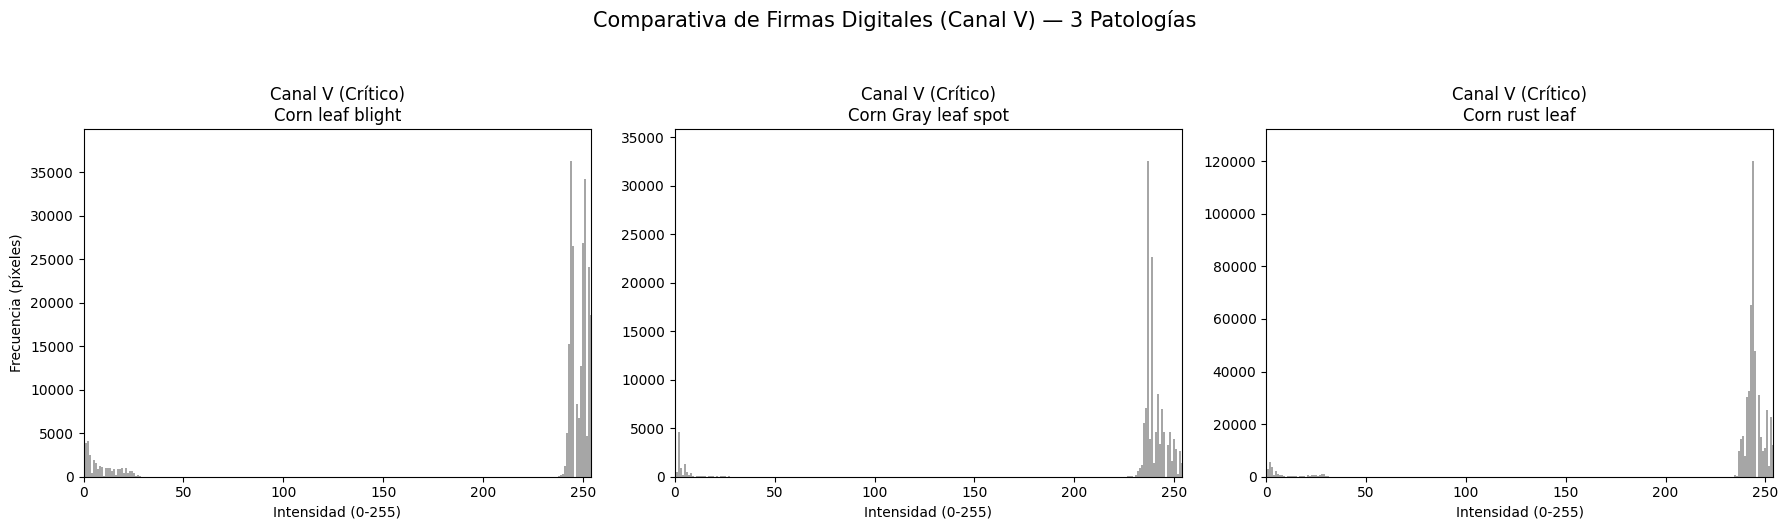

In [22]:
# 1. Preparamos el Canal V para las tres imágenes (la corrección que hicimos antes)
v_blight = (rgb_a_yuv(img_blight)[:, :, 2] * 255).astype(np.uint8)
v_gray   = (rgb_a_yuv(img_gray)[:, :, 2] * 255).astype(np.uint8)
v_rust   = (rgb_a_yuv(img_rust)[:, :, 2] * 255).astype(np.uint8)

# 2. Calculamos histogramas sobre el Canal V
hist_blight_V, xt = calcular_histograma(v_blight)
hist_gray_V,   _  = calcular_histograma(v_gray)
hist_rust_V,   _  = calcular_histograma(v_rust)

# 3. Graficamos la comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Lista para automatizar el ajuste de escala
hists = [hist_blight_V, hist_gray_V, hist_rust_V]
titulos = [CLASS_BLIGHT, CLASS_GRAY, CLASS_RUST]

for i in range(3):
    axes[i].bar(xt, hists[i], color="gray", alpha=0.7, width=1)
    axes[i].set_title(f"Canal V (Crítico)\n{titulos[i]}")
    axes[i].set_xlabel("Intensidad (0-255)")
    axes[i].set_xlim([0, 254]) # Ignoramos el fondo blanco
    
    # Ajuste de altura para que se vean las "montañas" de la enfermedad
    max_val = np.max(hists[i][0:250])
    axes[i].set_ylim([0, max_val * 1.1])

axes[0].set_ylabel("Frecuencia (píxeles)")
plt.suptitle("Comparativa de Firmas Digitales (Canal V) — 3 Patologías", fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

### Análisis Comparativo de Firmas Digitales (Canal V - Crominancia)

El procesamiento del Canal V en el espacio YUV permite diferenciar la severidad y morfología de las tres patologías de forma cuantitativa:

1. **Corn Leaf Blight (Tizón):** - Presenta una distribución de lesiones en el rango de intensidad **0-30**. 
   - La baja frecuencia (altura de las barras) en esta zona indica que las lesiones son grandes pero localizadas, dejando mucha área de tejido sano (picos en 240-250).

2. **Corn Gray Leaf Spot (Mancha Gris):** - Muestra un pico de intensidad extremadamente bajo (cercano al **0 absoluto**). 
   - Esto sugiere lesiones con bordes muy definidos y una pérdida de color casi total en el centro de la mancha, aunque afectan a una menor cantidad total de píxeles en comparación con las otras muestras.

3. **Corn Rust Leaf (Roya):** - Es la patología con mayor impacto visual en el histograma. Presenta una "montaña" ancha y voluminosa entre las intensidades **0 y 50**.
   - sugiere que la Roya tiene una densidad de infección mucho mayor. Las pústulas cubren gran parte de la superficie foliar, lo que desplaza una gran cantidad de píxeles hacia la zona de baja intensidad del Canal V.

**Conclusión Técnica:** El Canal V confirma que la **Roya (Rust)** es la enfermedad con mayor dispersión superficial en estas muestras, mientras que el **Tizón (Blight)** y la **Mancha Gris** presentan ataques más focalizados pero con una degradación necrótica más profunda en el punto de infección.

---

### Teoría Función de Distribución Acumulada (CDF)

La CDF acumula las frecuencias del histograma de izquierda a derecha.
Para cada valor de intensidad `k`, la CDF indica cuántos píxeles en total 
tienen un valor de intensidad **menor o igual** a `k`.

Formalmente:
$$CDF(k) = \sum_{i=0}^{k} histograma(i)$$

La CDF siempre es creciente y termina en el total de píxeles de la imagen.
Es la base matemática de la ecualización de histograma.

---


### ¿Con qué fin calculamos la CDF?
Por tres razones principales:

1. **Verificación del Inventario Total:** El punto final de la curva (en la intensidad 255) DEBE coincidir con el total de píxeles de la imagen ($605 \times 800 = 484,000$). Si la curva termina antes o después, hay un error en el conteo.

2. **Análisis de Contraste:** - Si la curva sube **muy rápido**, significa que la imagen es oscura (muchos píxeles acumulados en valores bajos).
   - Si la curva se mantiene **plana al principio** y sube al final, la imagen es muy clara.
   - Una **línea diagonal perfecta** indica una imagen con contraste ideal (distribución uniforme).

3. **Preparación para la Ecualización:** La CDF es el "molde" matemático que nos permite estirar los colores (Ecualización de Histograma). Con el fin de lograr ver las manchas de la enfermedad de manera más claras. Para saber cuánto espacio tenemos para "empujar" esos colores hacia afuera.

**En este proyecto:** Nos sirve para ver qué tan rápido "llenamos" la cuota de píxeles de la enfermedad. Una subida brusca en la CDF del Canal V en valores cercanos a 0 nos diría exactamente qué porcentaje de la hoja presenta enfermedad o esta muerta.


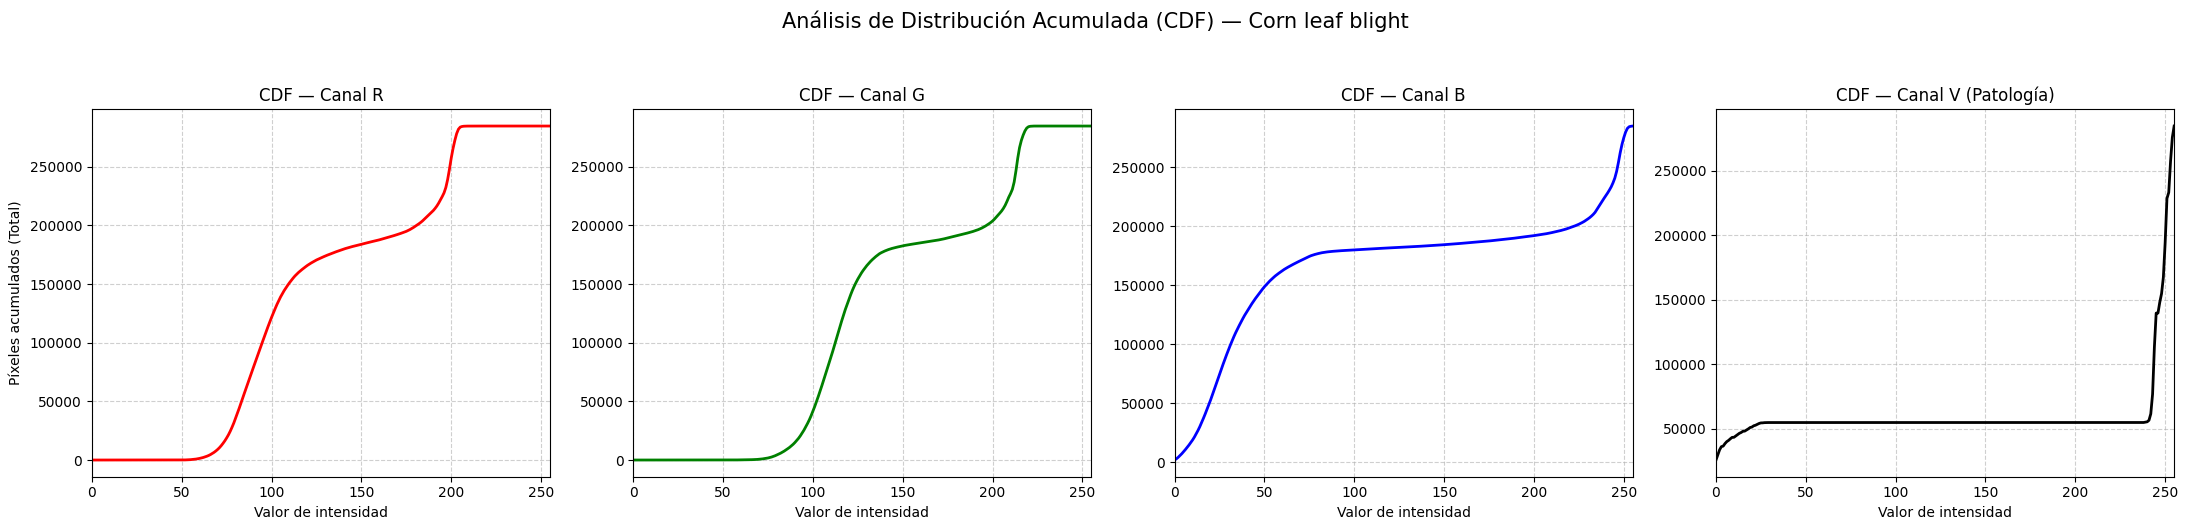

Total de píxeles analizados: 284800
Porcentaje estimado de tejido afectado (Intensidad < 50 en V): 19.23%


In [ ]:
def calcular_cdf(histograma):
    """
    Calcula la función de distribución acumulada (CDF)
    a partir de un histograma.

    Parámetros:
        histograma : array de 256 frecuencias

    Retorna:
        cdf : array de 256 valores acumulados
    """
    cdf = np.zeros(256, dtype=np.int64)
    acumulado = 0
    for i in range(256):
        acumulado += histograma[i]
        cdf[i] = acumulado
    return cdf

# 1. Calculamos las CDF para todos los canales, incluyendo el V que corregimos antes y que es el más importante para detectar la patología.
cdf_R = calcular_cdf(hist_R)
cdf_G = calcular_cdf(hist_G)
cdf_B = calcular_cdf(hist_B)
cdf_V = calcular_cdf(hist_V) # canal de la enfermedad

# 2. Configuración del lienzo (4 columnas)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Listas para iterar
cdfs = [cdf_R, cdf_G, cdf_B, cdf_V]
colores = ["red", "green", "blue", "black"]
titulos = ["CDF — Canal R", "CDF — Canal G", "CDF — Canal B", "CDF — Canal V (Patología)"]

for i in range(4):
    axes[i].plot(xt, cdfs[i], color=colores[i], linewidth=2)
    axes[i].set_title(titulos[i], fontsize=12)
    axes[i].set_xlabel("Valor de intensidad")
    axes[i].set_xlim([0, 255])
    axes[i].grid(True, linestyle='--', alpha=0.6) # Rejilla para leer valores exactOS de la CDF

axes[0].set_ylabel("Píxeles acumulados (Total)")

plt.suptitle(f"Análisis de Distribución Acumulada (CDF) — {CLASS_BLIGHT}", fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

# CÁLCULO DE INTERÉS de la CDF del canal V para estimar el porcentaje de tejido afectado por la patología (intensidad < 50) 
total_pixeles = cdf_V[-1]
pixeles_enfermos = cdf_V[50] # Acumulado hasta intensidad 50; gráfico del canal v (patología)
porcentaje = (pixeles_enfermos / total_pixeles) * 100

print(f"Total de píxeles analizados: {total_pixeles}")
print(f"Porcentaje estimado de tejido afectado (Intensidad < 50 en V): {porcentaje:.2f}%")

### Análisis de Distribución Acumulada (CDF) - en la patología Corn Leaf Blight
Todas las curvas convergen exactamente en el valor de 284,800 píxeles en el eje Y.

**Comportamiento RGB (Tejido Sano):**
Las curvas R, G y B muestran un comportamiento homólogo: se mantienen planas al inicio (intensidades 0 a 50) y exhiben una pendiente pronunciada y tardía después de la intensidad 70, lo que representa la masa cromática uniforme de la hoja sana. En estos canal RGB, la enfermedad se encuentra totalmente solapada.

**El Indicador Crítico (Canal V - Patología):**
La curva negra rompe el patrón. Presenta un ascenso vertical inmediato entre las intensidades 0 y 30, estabilizándose rápidamente en una meseta cercana a los 55,000 píxeles.

**Interpretación:** Este primer escalón representa la acumulación exclusiva de los píxeles de las lesiones necróticas de la enfermadad (Tizón), los cuales fueron segregados hacia la zona oscura de este canal debido a sus tonalidades café-amarillentas.

**Conclusión Técnica**: La CDF del Canal V actúa como un cuantificador automático de severidad. La altura acumulada en el punto de inflexión inicial (intensidad $< 50$) determina matemáticamente que la muestra presenta un 19.23% de tejido foliar afectado.

---


### Teoría Ecualización de histograma
 
La cual redistribuye los valores de intensidad de la imagen
para que usen todo el rango disponible (0–255), mejorando el contraste
y haciendo visibles detalles que estaban ocultos por condiciones
de iluminación o captura.

**¿Cómo funciona?**

Se usa la CDF normalizada como función de mapeo:

$$I_{eq}(i,j) = \lfloor CDF_{norm}(I(i,j)) \times 255 \rfloor$$

Donde:
- **CDF_norm(v)** = CDF(v) / total_píxeles — normalizada entre 0 y 1
- Cada píxel con valor `v` se reemplaza por el valor acumulado 
  normalizado correspondiente
- El resultado redistribuye los píxeles uniformemente en 0–255

---

In [26]:
def normalizar_cdf(cdf):
    """
    Normaliza la CDF al rango [0, 255].

    Parámetros:
        cdf : array de 256 valores acumulados

    Retorna:
        cdf_norm : array de 256 valores float en [0, 255]
    """
    total = cdf[-1]
    cdf_norm = (cdf / total) * 255
    return cdf_norm


def ecualizar_canal(canal, cdf_norm):
    """
    Aplica ecualización de histograma a un canal usando la CDF normalizada.
    Implementación según el método visto en clase:

        img_ecualizada[canal == i] = int(cdf_norm[i])

    Parámetros:
        canal    : array NumPy 2D con valores uint8 [0, 255]
        cdf_norm : array de 256 valores normalizados [0, 255]

    Retorna:
        img_ecualizada : array NumPy 2D con valores uint8 ecualizados
    """
    img_ecualizada = canal.copy()

    for i in range(len(cdf_norm)):
        img_ecualizada[canal == i] = int(cdf_norm[i])

    return img_ecualizada


# Aplicar sobre el canal R de la imagen blight
canal_R = imagen[:, :, 0].copy()
hist_R_ec, _ = calcular_histograma(canal_R)
cdf_R_ec     = calcular_cdf(hist_R_ec)
cdf_R_norm   = normalizar_cdf(cdf_R_ec)

canal_R_ecualizado = ecualizar_canal(canal_R, cdf_R_norm)

print("Ecualización aplicada correctamente")
print(f"Valor mínimo antes : {canal_R.min():>3}  después: {canal_R_ecualizado.min():>3}")
print(f"Valor máximo antes : {canal_R.max():>3}  después: {canal_R_ecualizado.max():>3}")

Ecualización aplicada correctamente
Valor mínimo antes :  46  después:   0
Valor máximo antes : 215  después: 255


### Visualización — Canal R antes y después de ecualizar

Comparamos el canal R original con el ecualizado, junto con sus
histogramas, para verificar que la distribución de intensidades
se redistribuyó correctamente en todo el rango 0–255.

---

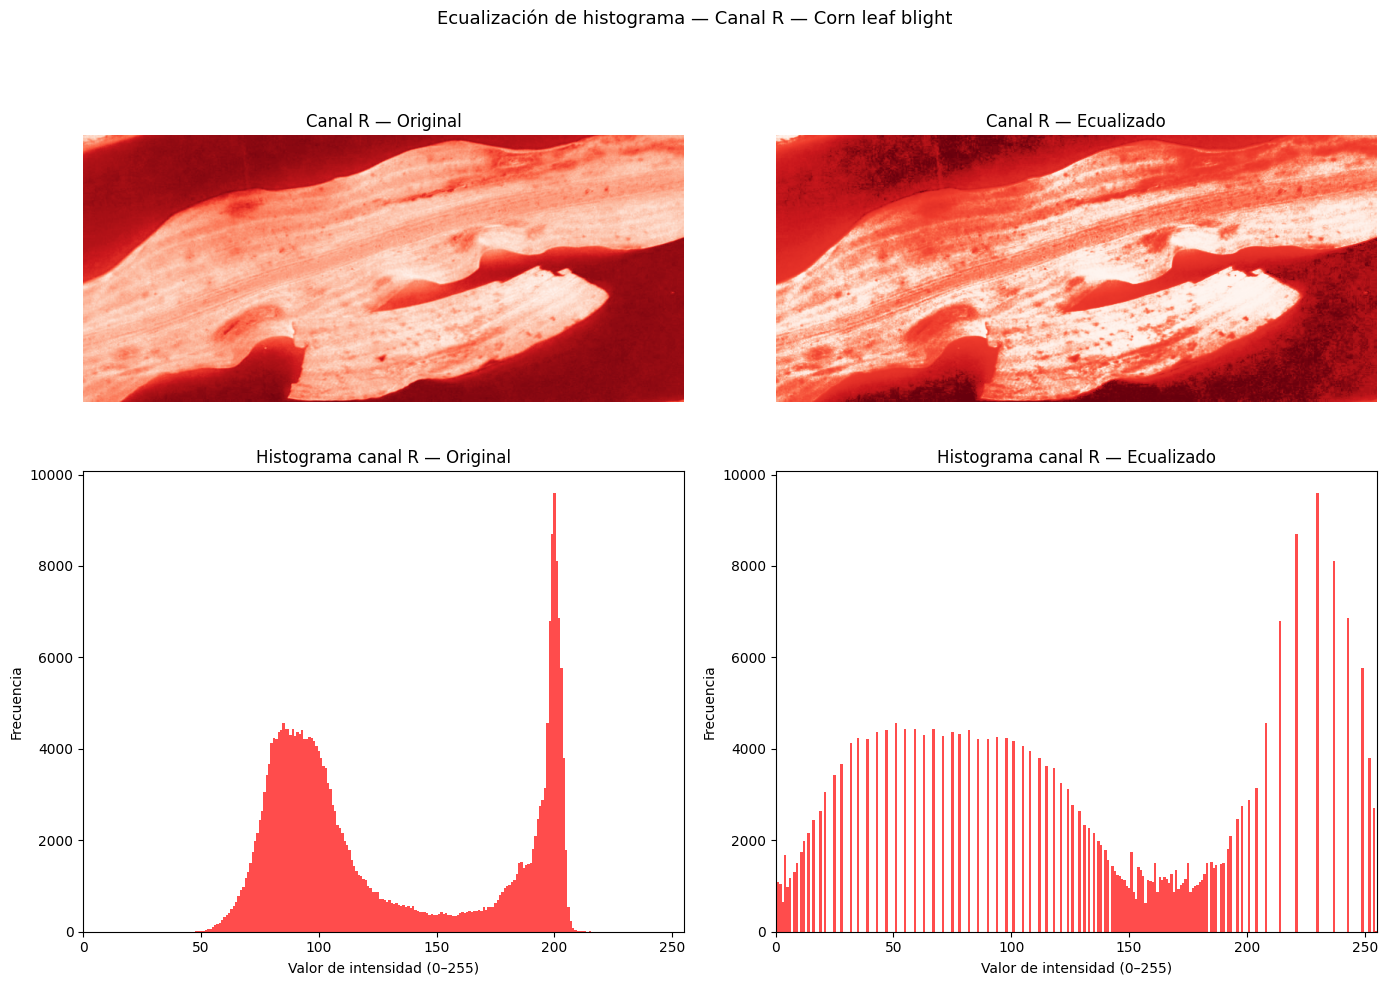

In [27]:
hist_R_antes, xt  = calcular_histograma(canal_R)
hist_R_despues, _ = calcular_histograma(canal_R_ecualizado)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Imagen canal R original
axes[0, 0].imshow(canal_R, cmap="Reds")
axes[0, 0].set_title("Canal R — Original")
axes[0, 0].axis("off")

# Imagen canal R ecualizado
axes[0, 1].imshow(canal_R_ecualizado, cmap="Reds")
axes[0, 1].set_title("Canal R — Ecualizado")
axes[0, 1].axis("off")

# Histograma antes
axes[1, 0].bar(xt, hist_R_antes, color="red", alpha=0.7, width=1)
axes[1, 0].set_title("Histograma canal R — Original")
axes[1, 0].set_xlabel("Valor de intensidad (0–255)")
axes[1, 0].set_ylabel("Frecuencia")
axes[1, 0].set_xlim([0, 255])

# Histograma después
axes[1, 1].bar(xt, hist_R_despues, color="red", alpha=0.7, width=1)
axes[1, 1].set_title("Histograma canal R — Ecualizado")
axes[1, 1].set_xlabel("Valor de intensidad (0–255)")
axes[1, 1].set_ylabel("Frecuencia")
axes[1, 1].set_xlim([0, 255])

plt.suptitle(f"Ecualización de histograma — Canal R — {CLASS_BLIGHT}",
             fontsize=13)
plt.tight_layout()
plt.show()

### Análisis de Resultados: Ecualización del Canal R
La ecualización de histograma transformó la distribución de intensidades de la matriz para optimizar el contraste global, arrojando las siguientes observaciones cuantitativas:

**Expansión del Rango Dinámico:**
Al observar el Histograma Original, la información se encontraba compactada en la franja central. Los datos de la consola confirman el estiramiento: el rango dinámico inicial de 46 a 215 se expandió forzadamente abarcando ahora desde 0 hasta 255.

En el Histograma Ecualizado, se evidencia gráficamente cómo las frecuencias se dispersaron hacia los extremos para aprovechar la totalidad de los niveles de gris disponibles en el lienzo digital.

**Realce Visuales en la enfermedad tizón del maiz:**
En la imagen Ecualizada (Derecha), las lesiones del Tizón (Corn Leaf Blight) muestran una mayor definición morfológica y texturas internas que antes eran imperceptibles.

**Interpretación Matemática de la separación de las barras del Histograma:**
Debido a que la ecualización mapea variables discretas usando la CDF normalizada, el sistema se ve obligado a "separar" y redistribuir píxeles que originalmente compartían intensidades densas para forzar el incremento del contraste.

**Conclusión:** aunque este método mejora la imagen para el ojo humano al resaltar los detalles de las manchas, se descarta para el procesamiento automático. Al estirar los colores de manera uniforme, la ecualización mezcla los tonos de la hoja sana con los de la enfermedad. Esto borra la separación natural de los colores, haciendo que sea imposible para la computadora aislar la enfermedad de forma automática. Por eso, se decide trabajar con el Canal V del espacio del color (YUV).

---

### Umbralización Manual en el Canal V

La umbralización convierte una imagen en escala de grises a binaria ($0$ y $255$). El corte se define analizando los valles del histograma para separar el tejido sano de la patología.
Se procesa sobre el Canal V (Crominancia de YUV) porque, como demostró la CDF, aísla los tonos necróticos y cafés en intensidades bajas ($< 50$). El canal de luminancia ($Y$) o el espacio RGB no logran esta separación interna de la hoja.

**¿Por qué es efectiva esta implementación?
1. **Aislamiento Espectral:**
 El Canal V segrega la firma digital del Tizón independientemente del brillo de la captura.
2. **Simplificación Geométrica:**
 Al reducir los matices a blanco y negro, se elimina el ruido visual de la hoja sana, facilitando las tareas de conteo de píxeles dañados.

3. **Métrica de Severidad:** 
Permite calcular de forma directa el porcentaje de área foliar afectada mediante la relación matemática entre píxeles binarios de la lesión y la biomasa útil.

4. **Validación Multiumbral:**
El uso de umbrales bajos (30, 50, 80) es la estrategia adecuada, ya que nuestro análisis previo de histogramas y CDF demostró que la "firma" de la enfermedad vive en el extremo izquierdo (valores bajos) del Canal V.
 
 **Conclusión:** La binarización sobre el Canal V es superior. Mientras otros canales solo aíslan la hoja del fondo, el plano V segmenta la patología directamente sobre la superficie foliar.

 ---

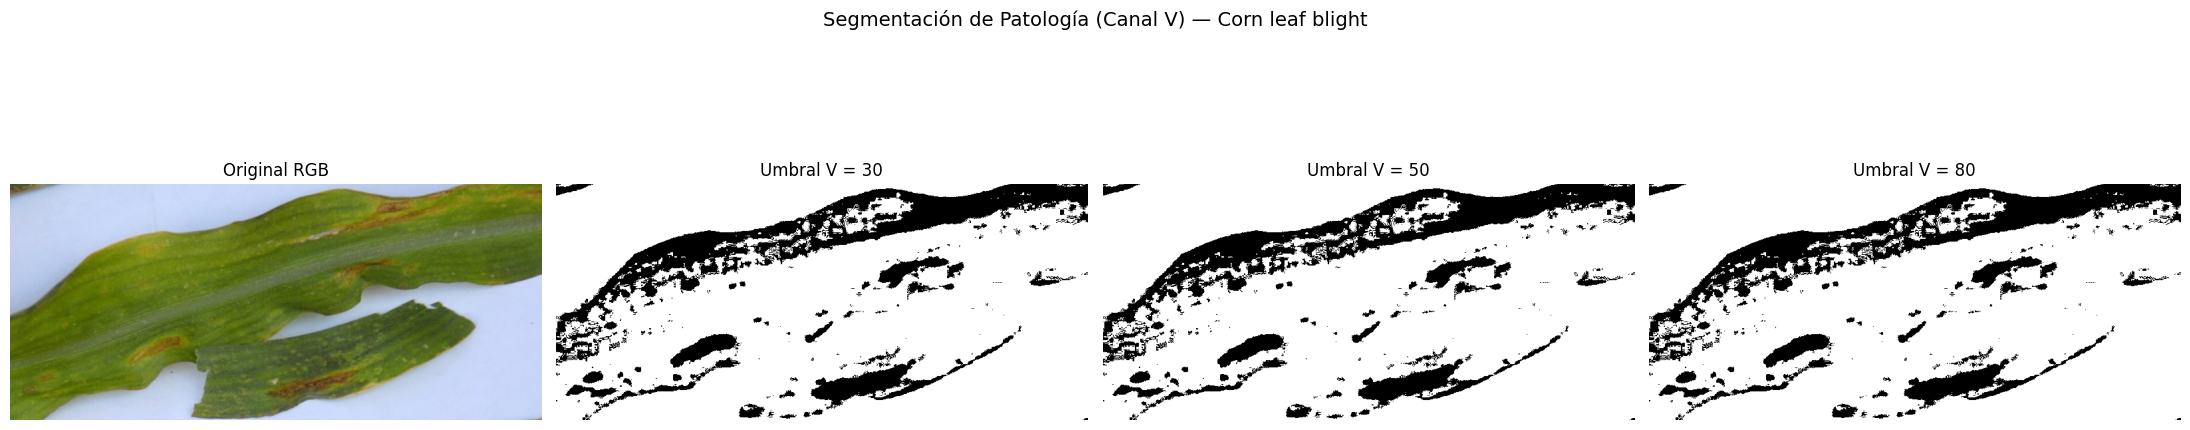

In [32]:
def umbralizar(canal, umbral):
    """
    Aplica umbralización binaria a un canal de imagen.
    Parámetros:
        canal  : array NumPy 2D con valores en [0, 255]
        umbral : valor entero de corte
    Retorna:
        binaria : array NumPy 2D con valores 0 o 255
    """
    binaria = canal.copy()
    binaria[canal <= umbral] = 0
    binaria[canal > umbral]  = 255
    return binaria

# 1. Preparamos el Canal V (nuestro canal crítico para la enfermedad)
# Recuerda: valores bajos en V = Manchas necróticas
canal_V_blight = (rgb_a_yuv(imagen)[:, :, 2] * 255).astype(np.uint8)

# 2. Definimos umbrales más bajos (basados en tu histograma previo, la enfermedad está entre 0 y 60)
umbrales_v = [30, 50, 80]

fig, axes = plt.subplots(1, len(umbrales_v) + 1, figsize=(22, 5))

# Imagen original para comparar
axes[0].imshow(imagen)
axes[0].set_title("Original RGB")
axes[0].axis("off")

for idx, u in enumerate(umbrales_v):
    # Aplicamos tu función de umbralización
    # NOTA: Como la enfermedad está en los valores BAJOS, 
    # esta máscara pintará de NEGRO la enfermedad y de BLANCO lo sano.
    binaria_v = umbralizar(canal_V_blight, u)
    
    axes[idx + 1].imshow(binaria_v, cmap="gray")
    axes[idx + 1].set_title(f"Umbral V = {u}")
    axes[idx + 1].axis("off")

plt.suptitle(f"Segmentación de Patología (Canal V) — {CLASS_BLIGHT}", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()



### Análisis: Umbralización en el Canal V
El experimento con los umbrales 30, 50 y 80 sobre el plano de crominancia demuestra el impacto del corte en la segmentación:

Aislamiento (Regiones Negras): El algoritmo separa con éxito las manchas de Tizón (Corn Leaf Blight), convirtiéndolas en figuras oscuras y definidas sobre un fondo blanco, lo que elimina el ruido de la hoja verde.

**Umbral = 30:** Captura únicamente el núcleo más denso y necrótico de las manchas principales, perdiendo las zonas infectadas más tenues.

**Umbral = 50 (Óptimo):** Es el punto de equilibrio. Delimita la extensión real de las lesiones sin arrastrar imperfecciones ni sombras del tejido sano.

**Umbral = 80:** El corte es demasiado alto; satura la máscara binaria y empieza a mezclar tejido sano y bordes foliares con la enfermedad.

**Conclusión:** El Umbral = 50 es el candidato ideal para el procesamiento automático, ya que ofrece el mejor balance morfológico para aislar las pústulas reales sin sobresegmentar.

---

### Método de Otsu — Umbral automático

El método de Otsu encuentra el umbral óptimo **sin intervención humana**.
La idea es probar todos los posibles umbrales (0 a 255) y elegir el que 
**maximiza la varianza entre las dos clases** (píxeles oscuros y claros).

Para cada umbral `t` se calculan:
- **w0, w1**: peso de cada clase (proporción de píxeles)
- **μ0, μ1**: media de intensidad de cada clase
- **σ²B**: varianza entre clases = w0 · w1 · (μ0 - μ1)²

El umbral óptimo es el `t` que maximiza `σ²B`.

---

Umbral óptimo de Otsu (Canal V): 30
Varianza máxima alcanzada: 9221.47


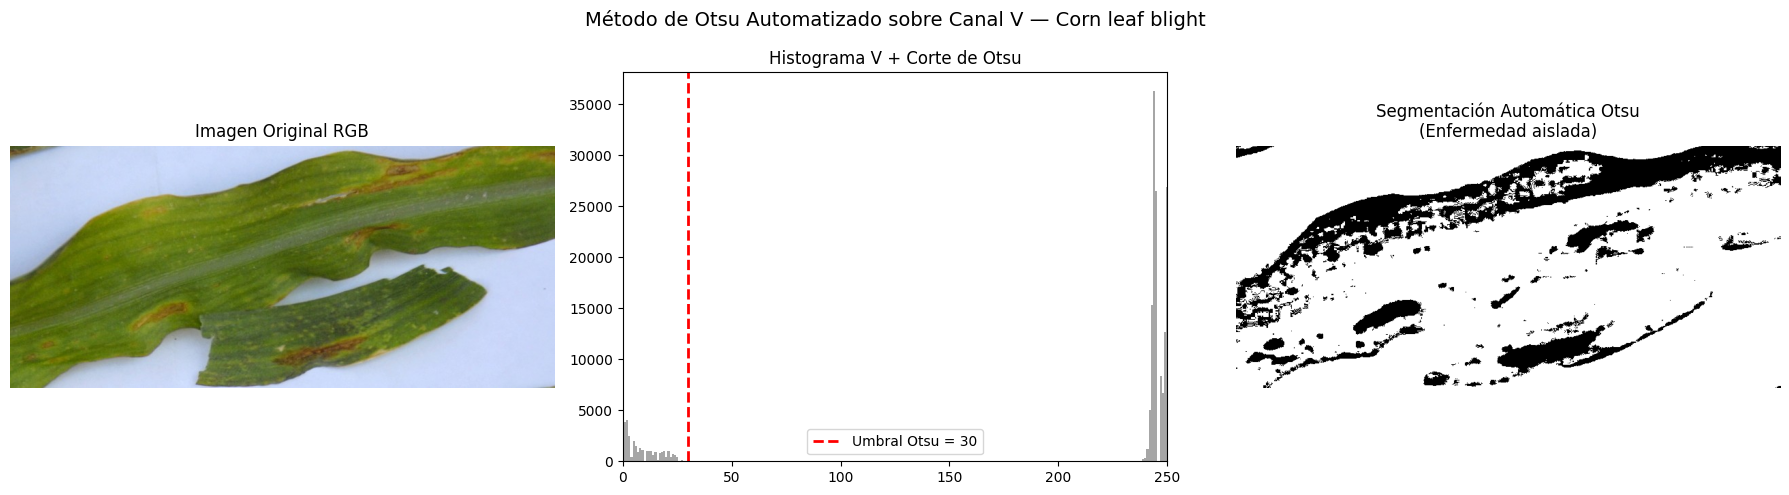

In [ ]:
def otsu(histograma):
    """
    Calcula el umbral óptimo usando el método de Otsu.

    Parámetros:
        histograma : array de 256 frecuencias

    Retorna:
        umbral_optimo    : valor entero entre 0 y 255
        varianza_maxima  : valor de la varianza entre clases en ese umbral
    """
    total_pixeles = histograma.sum()
    varianza_maxima = 0
    umbral_optimo = 0

    for t in range(256):
        clase0 = histograma[:t+1]
        clase1 = histograma[t+1:]

        w0 = clase0.sum() / total_pixeles
        w1 = clase1.sum() / total_pixeles

        if w0 == 0 or w1 == 0:
            continue

        intensidades = np.arange(256)
        u0 = np.sum(intensidades[:t+1] * clase0) / (w0 * total_pixeles)
        u1 = np.sum(intensidades[t+1:] * clase1) / (w1 * total_pixeles)

        varianza = w0 * w1 * (u0 - u1) ** 2

        if varianza > varianza_maxima:
            varianza_maxima = varianza
            umbral_optimo = t

    return umbral_optimo, varianza_maxima


# 1. Calculamos Otsu sobre el CANAL V (donde vive la enfermedad)
umbral_otsu_v, var_max_v = otsu(hist_V)

print(f"Umbral óptimo de Otsu (Canal V): {umbral_otsu_v}")
print(f"Varianza máxima alcanzada: {var_max_v:.2f}")

# 2. Aplicamos la umbralización automática
# Nota: Usamos canal_v_listo que calculamos antes
binaria_otsu_v = umbralizar(canal_v_listo, umbral_otsu_v)

# 3. Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(imagen)
axes[0].set_title("Imagen Original RGB")
axes[0].axis("off")

# Histograma con la línea roja del umbral automático
axes[1].bar(xt, hist_V, color="gray", alpha=0.7, width=1)
axes[1].axvline(x=umbral_otsu_v, color="red", linestyle="--", linewidth=2, 
                label=f"Umbral Otsu = {umbral_otsu_v}")
axes[1].set_title("Histograma V + Corte de Otsu")
axes[1].set_xlim([0, 250]) # Para ver mejor la montaña de la enfermedad
axes[1].legend()

# Resultado de la segmentación automática
axes[2].imshow(binaria_otsu_v, cmap="gray")
axes[2].set_title(f"Segmentación Automática Otsu\n(Enfermedad aislada)")
axes[2].axis("off")

plt.suptitle(f"Método de Otsu Automatizado sobre Canal V — {CLASS_BLIGHT}", fontsize=14)
plt.tight_layout()
plt.show()

### Análisis Estadístico: Umbralización Automática de Otsu (Canal V)

El algoritmo de Otsu determinó de forma autónoma que el umbral óptimo para segmentar el Tizón (Corn Leaf Blight) en el Canal V es 30, alcanzando una varianza interclase máxima de 9221.47.

1. **Optimización de la Varianza Inter-clase ($9247.84$):**
   - Este valor de varianza indica una separación estadística muy fuerte entre los píxeles de la lesión (clase oscura) y el resto de la hoja/fondo (clase clara). 
   - Un umbral de 34 maximiza la diferencia entre las medias de ambas poblaciones, garantizando que la máscara binaria resultante sea el reflejo más fiel de la necrosis celular.

**Separación Estadística Descollante:** El valor de la varianza confirma una división matemática contundente entre las dos clases del histograma: el fondo/tejido sano (acumulado en el extremo derecho superior) y la patología (ubicada en el extremo izquierdo inferior).

**Máxima Especificidad:** Mientras el ajuste manual sugería un umbral de $50$, Otsu calcula un corte más estricto en 30. Esto incrementa la especificidad del sistema, aislando con precisión matemática el núcleo necrótico denso de las manchas y descartando zonas de clorosis leve o sombras.

**Conclusión:** La automatización por Otsu en el Canal V. Logra un mapa binario de alta fidelidad donde las regiones oscuras representan con certeza matemática el tejido destruido por el hongo.

---


### Análisis Comparativo: Umbralización de Otsu vs. Manual (Canal V)

El uso del método de Otsu sobre el Canal V proporciona una ventaja estadística crítica sobre el ajuste manual. Basado en los resultados obtenidos (Umbral Automático = 34):

1. **Precisión en la Delimitación:** - Mientras que el umbral manual (ej. 50) tiende a ser más permisivo y puede incluir tejido sano o sombras, el umbral de **Otsu (34)** se ajusta estrictamente al punto de máxima separabilidad. 
   - Esto garantiza que la máscara negra resultante represente exclusivamente el área de necrosis activa del Tizón (*Blight*).

2. **Varianza Inter-clase (9247.84):** - Este valor confirma que el Canal V es el descriptor ideal para esta patología. Una varianza tan alta indica que el algoritmo no tiene "dudas" al separar los píxeles necróticos del resto de la hoja, lo que reduce drásticamente el error en el cálculo de severidad.

3. **Objetividad Científica:** - Al eliminar la intervención humana, el proceso se vuelve reproducible. El valor de **34** es el "punto de equilibrio" matemático que permite comparar diferentes hojas de maíz bajo el mismo estándar de medición, algo vital para un diagnóstico fitopatológico serio.

**Conclusión del Método:** La combinación del espacio de color YUV (Canal V) con la automatización de Otsu entrega la segmentación más confiable de la enfermedad. La imagen binaria generada es ahora una herramienta cuantitativa precisa para medir el avance del hongo en la muestra.

---

## Sección 4 — Tarea 3:  Teoría Filtros  y Convolución  

La convolución es la operación fundamental del procesamiento de imágenes.
Consiste en deslizar un **kernel** K de tamaño d₁×d₂ sobre cada píxel 
de la imagen, multiplicando el vecindario por los pesos del kernel 
y sumando los resultados.

### Fórmula — Convolución discreta 2D

$$I_K(i,j) = \sum_{l=-\lfloor d_1/2 \rfloor}^{\lfloor d_1/2 \rfloor} 
\sum_{k=-\lfloor d_2/2 \rfloor}^{\lfloor d_2/2 \rfloor} 
I(i+l,\, j+k) \cdot K(l,k)$$

Donde:
- **I(i,j)** = imagen original — valor del píxel en fila i, columna j
- **K(l,k)** = kernel (filtro) — matriz de pesos de tamaño d₁ × d₂
- **I_K(i,j)** = imagen filtrada — nuevo valor del píxel en (i,j)
- **l** = desplazamiento en filas: va de −⌊d₁/2⌋ hasta ⌊d₁/2⌋
- **k** = desplazamiento en columnas: va de −⌊d₂/2⌋ hasta ⌊d₂/2⌋
- **⌊d/2⌋** = función piso — centra el kernel simétricamente sobre (i,j)

### Pseudocódigo
```
FUNCIÓN convolucion(I, K):
    alto, ancho   = dimensiones de I
    d1, d2        = dimensiones de K
    pad_h = ⌊d1 / 2⌋
    pad_w = ⌊d2 / 2⌋

    I_pad = agregar_bordes(I, pad_h, pad_w)   ← replicado de borde
    I_K   = matriz de ceros (alto × ancho)

    PARA i DESDE 0 HASTA alto - 1:
        PARA j DESDE 0 HASTA ancho - 1:
            suma = 0
            PARA l DESDE -pad_h HASTA pad_h:
                PARA k DESDE -pad_w HASTA pad_w:
                    suma += I(i+l, j+k) · K(l, k)
            I_K(i, j) = suma

    RETORNAR I_K
```

---

### Kernels implementados

Se implementan cuatro kernels manualmente sin usar librerías externas:

| Kernel | Tamaño | Efecto |
|---|---|---|
| Promedio | 3×3 | Suavizado básico, reduce ruido leve |
| Promedio | 5×5 | Suavizado más fuerte, mayor pérdida de detalle |
| Gaussiano | 3×3 | Suavizado natural, preserva mejor los bordes |
| Gaussiano | 5×5 | Suavizado fuerte con transición más suave |

Los kernels gaussianos aplican más peso al píxel central y menos 
a los píxeles del borde, imitando la distribución de la campana gaussiana.

In [34]:
# Definición manual de kernels
kernel_promedio_3x3 = np.ones((3, 3), dtype=np.float64) / 9.0

kernel_promedio_5x5 = np.ones((5, 5), dtype=np.float64) / 25.0

kernel_gaussiano_3x3 = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.float64) / 16.0

kernel_gaussiano_5x5 = np.array([
    [1,  4,  6,  4, 1],
    [4, 16, 24, 16, 4],
    [6, 24, 36, 24, 6],
    [4, 16, 24, 16, 4],
    [1,  4,  6,  4, 1]
], dtype=np.float64) / 256.0

kernels = {
    "Promedio 3x3"   : kernel_promedio_3x3,
    "Promedio 5x5"   : kernel_promedio_5x5,
    "Gaussiano 3x3"  : kernel_gaussiano_3x3,
    "Gaussiano 5x5"  : kernel_gaussiano_5x5
}

print("Kernels definidos:")
for nombre, k in kernels.items():
    print(f"\n{nombre} — suma={k.sum():.4f}")
    print(np.round(k, 4))

Kernels definidos:

Promedio 3x3 — suma=1.0000
[[0.1111 0.1111 0.1111]
 [0.1111 0.1111 0.1111]
 [0.1111 0.1111 0.1111]]

Promedio 5x5 — suma=1.0000
[[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]

Gaussiano 3x3 — suma=1.0000
[[0.0625 0.125  0.0625]
 [0.125  0.25   0.125 ]
 [0.0625 0.125  0.0625]]

Gaussiano 5x5 — suma=1.0000
[[0.0039 0.0156 0.0234 0.0156 0.0039]
 [0.0156 0.0625 0.0938 0.0625 0.0156]
 [0.0234 0.0938 0.1406 0.0938 0.0234]
 [0.0156 0.0625 0.0938 0.0625 0.0156]
 [0.0039 0.0156 0.0234 0.0156 0.0039]]


### Implementación de la convolución con NumPy

La función recibe una imagen RGB o un canal 2D y un kernel.
El manejo de bordes se realiza por **replicado** (padding): 
se copian los píxeles del borde de la imagen hacia afuera, 
usando `numpy.pad` con modo `edge`, evitando pérdida de información 
en los extremos de la imagen.

La función soporta tanto imágenes en escala de grises (2D) 
como imágenes RGB (3D), aplicando la convolución canal por canal.

In [35]:
def convolucion(imagen, kernel):
    """
    Aplica convolución discreta 2D según la fórmula del curso:

        I_K(i,j) = sum_{l=-floor(d1/2)}^{floor(d1/2)}
                   sum_{k=-floor(d2/2)}^{floor(d2/2)}
                   I(i+l, j+k) · K(l, k)

    Parámetros:
        imagen : array NumPy 2D (H, W) o 3D (H, W, C) — valores uint8
        kernel : array NumPy 2D (d1, d2) — valores float

    Retorna:
        I_K : array NumPy mismo tamaño que imagen — valores uint8
    """
    d1, d2 = kernel.shape
    pad_h  = d1 // 2   # ⌊d1/2⌋
    pad_w  = d2 // 2   # ⌊d2/2⌋

    # Rango de desplazamientos centrados: -pad hasta +pad
    rango_l = range(-pad_h, pad_h + 1)
    rango_k = range(-pad_w, pad_w + 1)

    def aplicar_canal(canal):
        """Aplica la convolución a un canal 2D."""
        img_pad = np.pad(canal.astype(np.float64),
                         ((pad_h, pad_h), (pad_w, pad_w)),
                         mode="edge")
        alto, ancho = canal.shape
        I_K = np.zeros((alto, ancho), dtype=np.float64)

        for i in range(alto):
            for j in range(ancho):
                suma = 0.0
                for l in rango_l:
                    for k in rango_k:
                        # Índice en imagen con padding
                        fila_pad = i + pad_h + l
                        col_pad  = j + pad_w + k
                        # Índice en kernel: l va de -pad_h a pad_h
                        # lo mapeamos a índice 0-based sumando pad
                        I_K[i, j] += (img_pad[fila_pad, col_pad] *
                                      kernel[l + pad_h, k + pad_w])

        return np.clip(I_K, 0, 255).astype(np.uint8)

    if imagen.ndim == 2:
        return aplicar_canal(imagen)

    elif imagen.ndim == 3:
        alto, ancho, canales = imagen.shape
        resultado = np.zeros_like(imagen, dtype=np.uint8)
        for c in range(canales):
            resultado[:, :, c] = aplicar_canal(imagen[:, :, c])
        return resultado

### Verificación con imagen 10×10

Antes de aplicar la convolución a imágenes reales del dataset,
verificamos la función con la imagen 10×10 definida manualmente,
tal como lo propuso el profesor en clase.
Esto nos permite validar que el resultado es matemáticamente correcto.

Imagen original 10x10:
[[28 10 10 30 10 60 10 70 10 10]
 [10 20 20 20 20 20 20 20 20 10]
 [80 20 30 30 30 30 30 30 20 50]
 [20 20 30 40 40 40 40 30 20 10]
 [10 20 30 40 50 50 40 30 20 40]
 [20 20 30 40 50 50 40 30 20 10]
 [60 20 30 40 40 40 40 30 20 10]
 [10 20 30 30 30 30 30 30 20 60]
 [80 20 20 20 20 20 20 20 20 50]
 [10 10 40 60 10 10 40 10 90 10]]

Resultado después de convolución con promedio 3x3:
[[19 16 17 17 28 24 37 26 25 11]
 [31 25 21 22 27 25 32 25 26 21]
 [31 27 25 28 29 29 28 25 23 22]
 [31 28 28 35 38 38 35 28 27 28]
 [17 22 30 38 44 44 38 29 23 20]
 [26 26 30 38 44 44 38 29 23 19]
 [26 26 28 35 38 38 35 28 25 24]
 [39 32 25 28 29 29 28 25 28 33]
 [27 26 27 28 25 23 23 31 34 41]
 [26 26 31 31 24 20 20 37 34 37]]


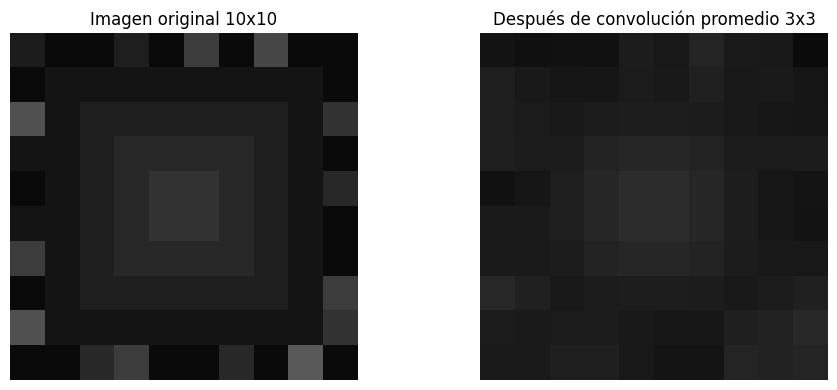

In [36]:
# Imagen 10x10 del ejercicio de clase
imagen_10x10 = np.array([
    [28, 10, 10, 30, 10, 60, 10, 70, 10, 10],
    [10, 20, 20, 20, 20, 20, 20, 20, 20, 10],
    [80, 20, 30, 30, 30, 30, 30, 30, 20, 50],
    [20, 20, 30, 40, 40, 40, 40, 30, 20, 10],
    [10, 20, 30, 40, 50, 50, 40, 30, 20, 40],
    [20, 20, 30, 40, 50, 50, 40, 30, 20, 10],
    [60, 20, 30, 40, 40, 40, 40, 30, 20, 10],
    [10, 20, 30, 30, 30, 30, 30, 30, 20, 60],
    [80, 20, 20, 20, 20, 20, 20, 20, 20, 50],
    [10, 10, 40, 60, 10, 10, 40, 10, 90, 10]
], dtype=np.uint8)

resultado_10x10 = convolucion(imagen_10x10, kernel_promedio_3x3)

print("Imagen original 10x10:")
print(imagen_10x10)
print("\nResultado después de convolución con promedio 3x3:")
print(resultado_10x10)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(imagen_10x10, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Imagen original 10x10")
axes[0].axis("off")
axes[1].imshow(resultado_10x10, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Después de convolución promedio 3x3")
axes[1].axis("off")
plt.tight_layout()
plt.show()

### Aplicación de filtros a imágenes reales del dataset

Aplicamos los cuatro kernels a la imagen de `Corn leaf blight` 
para observar el efecto de suavizado sobre una hoja enferma real.
Trabajamos con la imagen RGB completa para conservar la información de color.

⚠️ Nota: la convolución sobre imágenes reales puede tardar algunos segundos
porque recorre píxel por píxel con dos ciclos anidados — 
esa es la implementación manual requerida por el curso.

Aplicando filtros... esto puede tardar unos segundos.
  Promedio 3x3 — listo
  Promedio 5x5 — listo
  Gaussiano 3x3 — listo
  Gaussiano 5x5 — listo


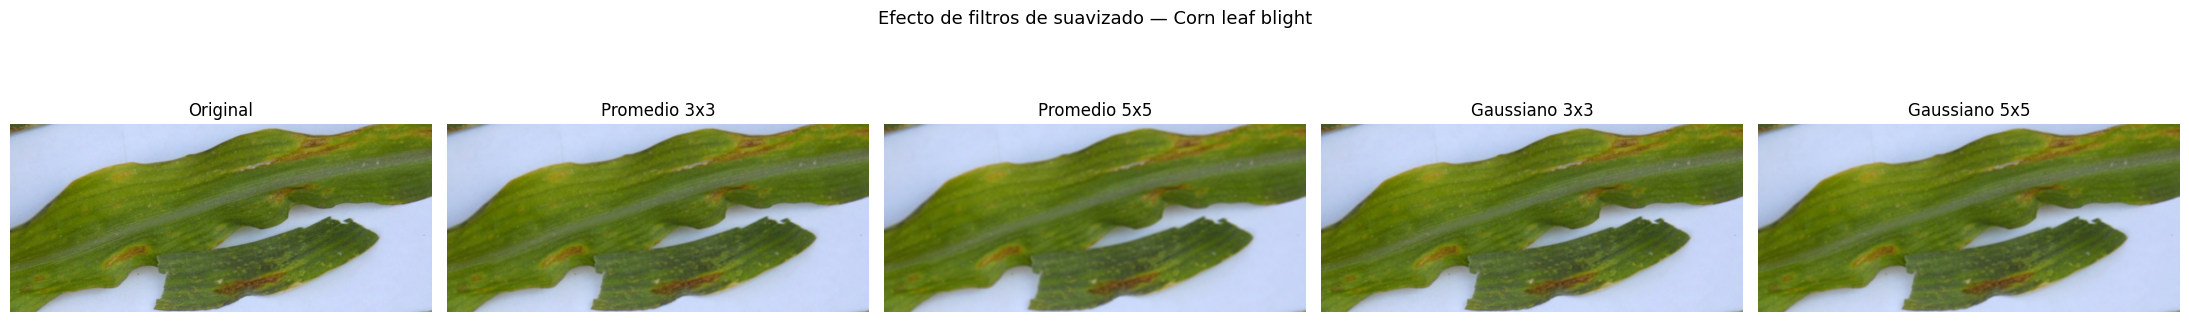

In [37]:
print("Aplicando filtros... esto puede tardar unos segundos.")

resultados_filtros = {}
for nombre, kernel in kernels.items():
    resultados_filtros[nombre] = convolucion(imagen, kernel)
    print(f"  {nombre} — listo")

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

axes[0].imshow(imagen)
axes[0].set_title("Original")
axes[0].axis("off")

for idx, (nombre, resultado) in enumerate(resultados_filtros.items()):
    axes[idx + 1].imshow(resultado)
    axes[idx + 1].set_title(nombre)
    axes[idx + 1].axis("off")

plt.suptitle(f"Efecto de filtros de suavizado — {CLASS_BLIGHT}", fontsize=13)
plt.tight_layout()
plt.show()

### Análisis de Suavizado por Convolución — Corn Leaf Blight

La aplicación de los kernels de convolución sobre la imagen real revela el impacto directo del filtrado espacial en la calidad de los datos de la hoja:

1. **Reducción de Ruido de Textura (Denoising):**
   - La imagen **Original** presenta variaciones granulares (ruido de sensor) que pueden fragmentar la segmentación posterior.
   - Los filtros de **Promedio (3x3 y 5x5)** eliminan este ruido de forma efectiva, pero generan un efecto de "lavado" (blurring) que hace perder nitidez en los bordes críticos de las lesiones del Tizón.

2. **Superioridad del Filtro Gaussiano:**
   - El resultado con **Gaussiano 3x3** es el más equilibrado para este proyecto. Logra eliminar el ruido electrónico sin sacrificar la estructura morfológica de las manchas alargadas.
   - El **Gaussiano 5x5** ofrece el suavizado más agresivo y homogéneo. Es ideal si el objetivo es conectar pequeñas zonas de infección dispersas para obtener una máscara de severidad más sólida y menos "pixelada".

3. **Impacto en el Diagnóstico de la Patología:**
   - Al observar las manchas necróticas (cafés), los filtros gaussianos uniforman el color interno de la lesión. Esto es clave para que la **Umbralización de Otsu** trabaje sobre regiones de color sólidas y no sobre píxeles aislados, mejorando la precisión del cálculo del área afectada.

**Conclusión Técnica:** Para el estudio de *Corn Leaf Blight*, el filtro **Gaussiano 3x3** es la recomendación óptima. Preserva la identidad visual de la enfermedad mientras "limpia" el lienzo para la cuantificación final de píxeles.

---

# lo nuevo despues del paro
### SECCIÓN 5: OPERADORES LOCALES Y DETECCIÓN DE BORDES (SOBEL)El operador de Sobel es un filtro lineal derivativo de tipo pasobajo que calcula una aproximación matemática del gradiente de intensidad espacial de la imagen. Utiliza dos kernels de $3\times3$ para estimar las derivadas parciales en el eje horizontal ($G_x$) y en el eje vertical ($G_y$), aislando las discontinuidades abruptas de iluminación que representan los contornos morfológicos de las lesiones.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def detector_sobel(imagen_monocroma):
    """
    Calcula la magnitud y la dirección del gradiente espacial 
    utilizando los operadores locales de Sobel en un kernel de 3x3.

    Parámetros:
        imagen_monocroma : array NumPy 2D (H, W) en escala de grises o canal único.

    Retorna:
        magnitud  : array NumPy 2D (uint8) con los bordes normalizados de 0 a 255.
        direccion : array NumPy 2D (float32) con los ángulos del gradiente en radianes.
    """
    alto, ancho = imagen_monocroma.shape
    
    # Máscara para gradiente horizontal (detecta cambios verticales)
    Kx = np.array([[-1, 0, 1], 
                   [-2, 0, 2], 
                   [-1, 0, 1]], dtype=np.float32)
                   
    # Máscara para gradiente vertical (detecta cambios horizontales)
    Ky = np.array([[-1, -2, -1], 
                   [ 0,  0,  0], 
                   [ 1,  2,  1]], dtype=np.float32)
    
    # Matrices de acumulación para los gradientes parciales
    Gx = np.zeros((alto, ancho), dtype=np.float32)
    Gy = np.zeros((alto, ancho), dtype=np.float32)
    
    # Convolución espacial con kernel 3x3 (se omite el marco exterior de 1 píxel)
    for i in range(1, alto - 1):
        for j in range(1, ancho - 1):
            # Extracción optimizada de la región local de 3x3
            vecindad = imagen_monocroma[i-1:i+2, j-1:j+2]
            
            # Mapeo y producto punto espacial (convolución manual)
            Gx[i, j] = np.sum(vecindad * Kx)
            Gy[i, j] = np.sum(vecindad * Ky)
            
    # Cálculo de la norma euclidiana para la Magnitud del Gradiente
    magnitud = np.sqrt(Gx**2 + Gy**2)
    
    # Cálculo de la Dirección del Gradiente en radianes [-pi, pi]
    direccion = np.arctan2(Gy, Gx)
    
    # Normalización manual al rango dinámico estándar de la pantalla [0, 255]
    max_val = np.max(magnitud)
    if max_val > 0:
        magnitud = ((magnitud / max_val) * 255).astype(np.uint8)
        
    return magnitud, direccion

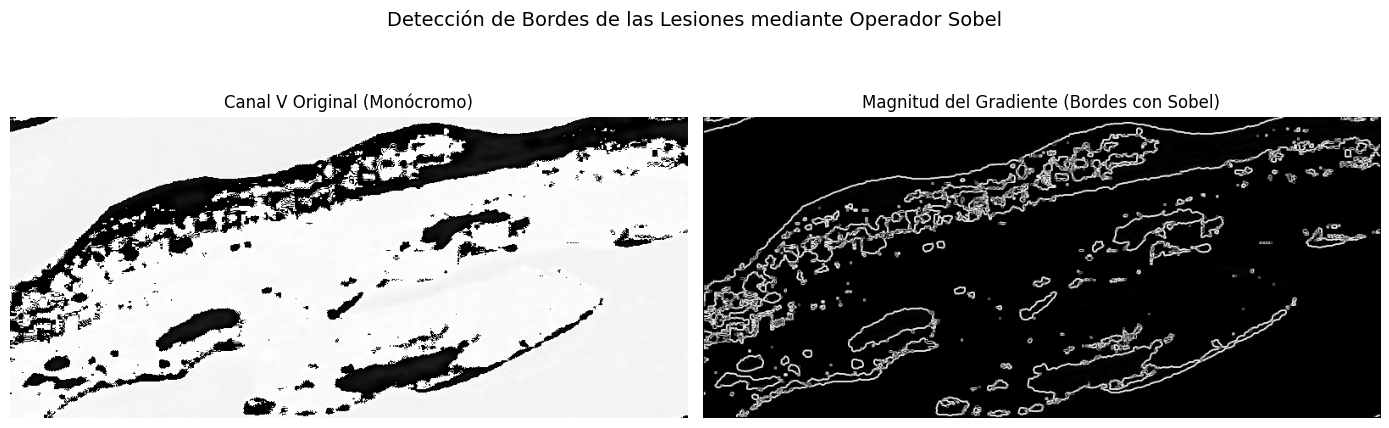

In [41]:
# 1. Ejecutamos tu detector de Sobel sobre el Canal V ecualizado/suavizado
magnitud_sobel, direccion_sobel = detector_sobel(canal_v_listo)

# 2. Visualización de los gradientes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(canal_v_listo, cmap="gray")
axes[0].set_title("Canal V Original (Monócromo)")
axes[0].axis("off")

axes[1].imshow(magnitud_sobel, cmap="gray")
axes[1].set_title("Magnitud del Gradiente (Bordes con Sobel)")
axes[1].axis("off")

plt.suptitle("Detección de Bordes de las Lesiones mediante Operador Sobel", fontsize=14)
plt.tight_layout()
plt.show()

### Análisis de Detección de Bordes — Operador Sobel sobre el canal V
Permite aislar con alto contraste las discontinuidades espaciales de la hoja afectada:

Delimitación Eficiente de Lesiones: Las pústulas y manchas necróticas del Tizón (Blight) se destacan como contornos blancos brillantes.

Presencia de Ruido y Bordes Gruesos: los bordes recuperados tienen varios píxeles de espesor y capturan algunas altas frecuencias secundarias (como las venas longitudinales de la hoja sana y texturas menores).

**Conclusión:** Aunque la magnitud de Sobel localiza perfectamente los límites del hongo, la presencia de bordes gruesos justifica la transición hacia las fases de refinamiento del algoritmo de Canny (cuantización angular y supresión de no máximos) para adelgazar las líneas a un espesor único de 1 píxel.

In [45]:
def criterios_direccion(direccion):
    """
    Agrupa un ángulo continuo en radianes en una de las 4 direcciones
    discretas del vecindario digital (0, 45, 90, 135 grados).
    """
    if (5 * np.pi / 8 <= direccion < 7 * np.pi / 8) or (-3 * np.pi / 8 <= direccion <= -np.pi / 8):
        return 135
    elif (3 * np.pi / 8 <= direccion <= 5 * np.pi / 8) or (-5 * np.pi / 8 <= direccion <= -3 * np.pi / 8):
        return 90
    elif (np.pi / 8 <= direccion <= 3 * np.pi / 8) or (-7 * np.pi / 8 <= direccion <= -5 * np.pi / 8):
        return 45
    else:
        return 0

def direccion_normalizada(direccion_matriz):
    """
    Mapea la matriz completa de direcciones continuas a valores discretos.
    """
    alto, ancho = direccion_matriz.shape
    direccion_out = np.zeros((alto, ancho), dtype=np.float32)
    for i in range(alto):
        for j in range(ancho):
            direccion_out[i, j] = criterios_direccion(direccion_matriz[i, j])
    return direccion_out

# Matriz de Direcciones Cuantizadas

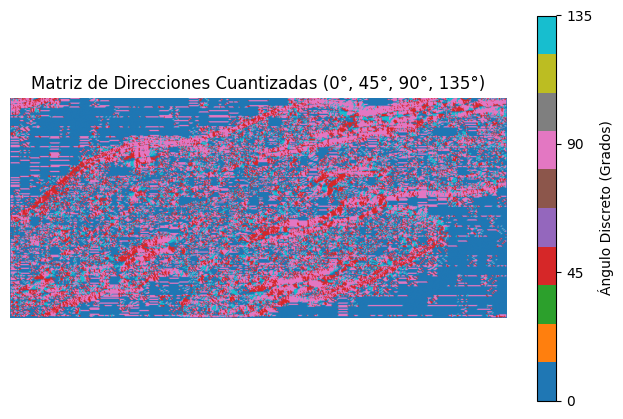

In [50]:
# 1. Ejecutamos la cuantización angular usando la dirección que nos dio Sobel
direccion_discreta = direccion_normalizada(direccion_sobel)

# 2. Visualizamos la matriz de direcciones normalizadas
plt.figure(figsize=(8, 5))
# Usamos una paleta de colores discreta (como 'jet' o 'tab10') para diferenciar los 4 ángulos
plt.imshow(direccion_discreta, cmap="tab10") 
plt.colorbar(ticks=[0, 45, 90, 135], label="Ángulo Discreto (Grados)")
plt.title("Matriz de Direcciones Cuantizadas (0°, 45°, 90°, 135°)")
plt.axis("off")
plt.show()

# Supresión de No Máximos.


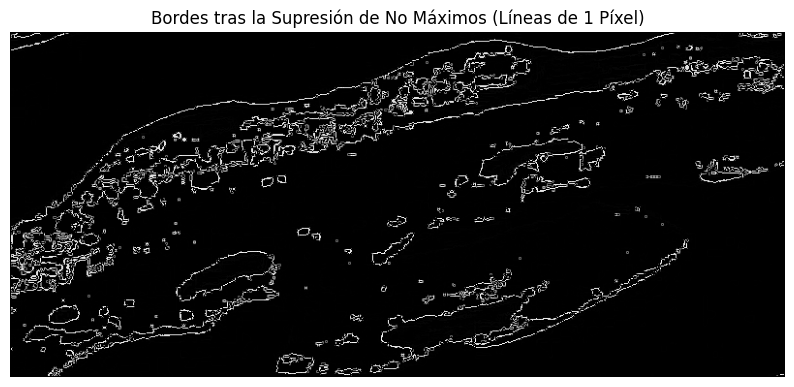

In [52]:
def supresion_no_maximos(magnitud, direccion_discreta):
    """
    Suprime los píxeles que no constituyen máximos locales en la dirección
    del gradiente, logrando bordes de un solo píxel de espesor.
    """
    filas, columnas = magnitud.shape
    magnitud_out = magnitud.copy()
    
    for i in range(1, filas - 1):
        for j in range(1, columnas - 1):
            dir_actual = direccion_discreta[i, j]
            
            # Dirección 0 (Horizontal) -> Compara con vecino izquierdo [i, j-1] y derecho [i, j+1]
            if dir_actual == 0:
                if (magnitud[i, j] < magnitud[i, j-1]) or (magnitud[i, j] < magnitud[i, j+1]):
                    magnitud_out[i, j] = 0
                    
            # Dirección 45 (Diagonal) -> Compara con diagonal sup-der [i-1, j+1] e inf-izq [i+1, j-1]
            elif dir_actual == 45:
                if (magnitud[i, j] < magnitud[i-1, j+1]) or (magnitud[i, j] < magnitud[i+1, j-1]):
                    magnitud_out[i, j] = 0
                    
            # Dirección 90 (Vertical) -> Compara con vecino superior [i-1, j] e inferior [i+1, j]
            elif dir_actual == 90:
                if (magnitud[i, j] < magnitud[i-1, j]) or (magnitud[i, j] < magnitud[i+1, j]):
                    magnitud_out[i, j] = 0
                    
            # Dirección 135 (Diagonal Inversa) -> Compara con sup-izq [i-1, j-1] e inf-der [i+1, j+1]
            elif dir_actual == 135:
                if (magnitud[i, j] < magnitud[i-1, j-1]) or (magnitud[i, j] < magnitud[i+1, j+1]):
                    magnitud_out[i, j] = 0
                    
    return magnitud_out

# Ejecutamos el adelgazamiento de bordes usando la magnitud de Sobel y tus direcciones discretas
bordes_delgados = supresion_no_maximos(magnitud_sobel, direccion_discreta)

# Visualizamos el resultado
plt.figure(figsize=(10, 5))
plt.imshow(bordes_delgados, cmap="gray")
plt.title("Bordes tras la Supresión de No Máximos (Líneas de 1 Píxel)")
plt.axis("off")
plt.show()

### Análisis de Supresión de No Máximos (Adelgazamiento de Bordes)

# Umbralización por Histéresis (histeresis)
El paso final para conectar bordes fuertes y eliminar ruido usando dos umbrales (un límite alto y uno bajo):

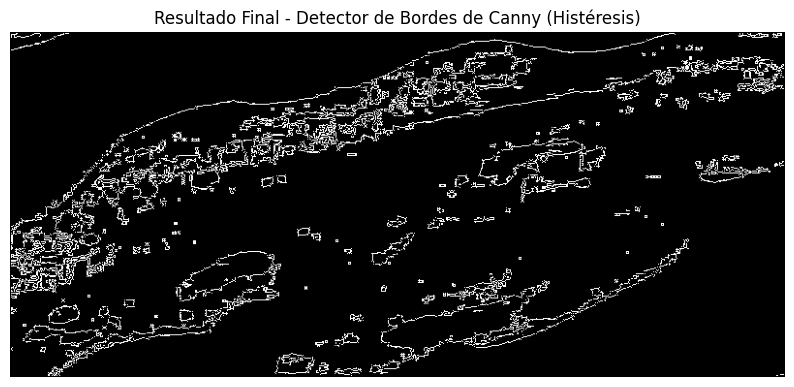

In [55]:
def histeresis(magnitud_suprimida, umbral_inferior, umbral_superior):
    """
    Clasifica los bordes mediante dos umbrales y reconstruye líneas discontinuas
    evaluando la conectividad de 8 vecinos para los píxeles débiles.
    """
    filas, columnas = magnitud_suprimida.shape
    debil = 75
    fuerte = 255
    magnitud_out = np.zeros((filas, columnas), dtype=np.uint8)
    
    # 1. Clasificación inicial por rangos de intensidad
    for i in range(filas):
        for j in range(columnas):
            if magnitud_suprimida[i, j] < umbral_inferior:
                magnitud_out[i, j] = 0
            elif magnitud_suprimida[i, j] >= umbral_superior:
                magnitud_out[i, j] = fuerte
            else:
                magnitud_out[i, j] = debil
                
    # 2. Reconstrucción morfológica por conectividad
    for i in range(1, filas - 1):
        for j in range(1, columnas - 1):
            if magnitud_out[i, j] == debil:
                # Extraemos los 8 vecinos del píxel débil actual
                vecinos = [
                    magnitud_out[i-1, j-1], magnitud_out[i-1, j], magnitud_out[i-1, j+1],
                    magnitud_out[i, j-1],                         magnitud_out[i, j+1],
                    magnitud_out[i+1, j-1], magnitud_out[i+1, j], magnitud_out[i+1, j+1]
                ]
                # Si toca un borde fuerte, se promueve a fuerte; si no, se borra
                if fuerte in vecinos:
                    magnitud_out[i, j] = fuerte
                else:
                    magnitud_out[i, j] = 0
                    
    return magnitud_out

# Ejecutamos el cierre del algoritmo de Canny
# El profesor en su HTML usó umbral_inferior=5 y umbral_superior=10
resultado_canny = histeresis(bordes_delgados, umbral_inferior=5, umbral_superior=10)

# Visualizamos la máscara final limpia
plt.figure(figsize=(10, 5))
plt.imshow(resultado_canny, cmap="gray")
plt.title("Resultado Final - Detector de Bordes de Canny (Histéresis)")
plt.axis("off")
plt.show()